In [18]:
import h5py
import numpy as np
import math
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Helpers & Statistics
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    if err <= 0: return f"{mean}"
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
    else:
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1)) 
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
    return fitted_params

# ---------------------------------------------------------
# 2. Extrapolation Routine for Parameters
# ---------------------------------------------------------
def fit_param_linear(inv_zeta_vals, param_jk_samples):
    """
    Fits y = c0 + c1 * (1/zeta_hat) for a given parameter.
    """
    N_PL, N_JK = param_jk_samples.shape

    mean_y = np.mean(param_jk_samples, axis=1)
    cov_y = np.cov(param_jk_samples, bias=True) * (N_JK - 1)

    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    # Linear fit in 1/zeta_hat
    def fcn(x, p):
        return p['c0'] + p['c1'] * x**2

    prior = {'c0': gv.gvar(0, 5000000), 'c1': gv.gvar(0, 5000000)}

    # JK fits
    c0_jk = []
    c1_jk = []
    chi2_dof = []
    cov_y_eval = gv.evalcov(y_gvar)

    for k in range(N_JK):
        y_k_gvar = gv.gvar(param_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_k_gvar), fcn=fcn, prior=prior)
        chi2_dof.append(fit_k.chi2 / fit_k.dof)
        c0_jk.append(fit_k.pmean['c0'])
        c1_jk.append(fit_k.pmean['c1'])

    return np.array(c0_jk), np.array(c1_jk), np.array(chi2_dof)

# ---------------------------------------------------------
# 3. Main Routine
# ---------------------------------------------------------
def parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=200):
    
    lata = 0.11403
    mass_filepath = "/pscratch/sd/h/hari_8/TMD_fit/h5data/MassN_Jackknife.h5"
    with h5py.File(mass_filepath, "r") as f:
        # This loads the mass array of shape (N_JK,)
        MassN_jk = f[f"PL_{-1}"][:] 
    massterm = MassN_jk * (197.32698 * 0.001 / lata)

    pl_to_zeta = {
        -4: 0.785756,
        -3: 0.539684,
        -2: 0.294367,
        -1: 0.090772
    }
    
    inv_zeta_vals = np.array([1.0 / pl_to_zeta[pl] for pl in PL_list])
    sort_idx = np.argsort(inv_zeta_vals)
    inv_zeta_vals = inv_zeta_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)
    
    # Create dynamic PL string for filenames (e.g. [-2, -3, -4] -> "234")
    pl_str = "".join([str(abs(p)) for p in sorted(PL_list, reverse=True)])
    
    # Load Initial Data to get N_JK
    init_filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])

    # Dictionary to hold the scaled parameters for all PLs
    param_names = ['a_re', 'c_re', 'j_re', 'd_re', 
                   'a_im', 'c_im', 'j_im', 'd_im', 
                   'a_reA12B', 'c_reA12B', 'j_reA12B', 'd_reA12B']
                   
    raw_data = {p: np.zeros((N_PL, N_JK)) for p in param_names}

    print("[1] Loading and Scaling Parameters...")
    for i, pl in enumerate(sorted_PL_list):
        filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        params = load_params_from_h5(filename)
        
        # Apply scaling rules
        raw_data['a_re'][i, :] = params['a_re']
        raw_data['c_re'][i, :] = params['c_re'] / (pl**2)
        raw_data['j_re'][i, :] = params['j_re']
        raw_data['d_re'][i, :] = params['d_re']
        
        raw_data['a_im'][i, :] = params['a_im'] / pl
        raw_data['c_im'][i, :] = params['c_im'] / (pl**2)
        raw_data['j_im'][i, :] = params['j_im']
        raw_data['d_im'][i, :] = params['d_im']
        
        raw_data['a_reA12B'][i, :] = params['a_reA12B']
        raw_data['c_reA12B'][i, :] = params['c_reA12B'] / (pl**2)
        raw_data['j_reA12B'][i, :] = params['j_reA12B']
        raw_data['d_reA12B'][i, :] = params['d_reA12B']

    print("[2] Extrapolating Parameters to 1/zeta_hat -> 0...")
    extrapolated_jk = {}
    
    # Plotting setup for parameters
    fig_p, axes_p = plt.subplots(3, 4, figsize=(18, 12))
    axes_p = axes_p.flatten()
    plot_x = np.linspace(0, max(inv_zeta_vals)*1.1, 50)

    for idx, p_name in enumerate(param_names):
        jk_samples = raw_data[p_name]
        
        # Fit
        c0_jk, c1_jk, chi2 = fit_param_linear(inv_zeta_vals, jk_samples)
        extrapolated_jk[p_name] = c0_jk
        
        # Get means and errors for the raw data points
        y_means = np.mean(jk_samples, axis=1)
        y_errs = [Jackknife(jk_samples[i, :])[1] for i in range(N_PL)]
        
        # Generate Error Band for the fit line
        fit_m = np.zeros(len(plot_x))
        fit_e = np.zeros(len(plot_x))
        for i_x, px in enumerate(plot_x):
            # Evaluate the linear fit at this x for all JK samples
            jk_vals_at_x = c0_jk + c1_jk * px**2
            fit_m[i_x], fit_e[i_x] = Jackknife(jk_vals_at_x)
        
        c0_m, c0_e = Jackknife(c0_jk)
        
        # Plot
        ax = axes_p[idx]
        ax.errorbar(inv_zeta_vals, y_means, yerr=y_errs, fmt='o', color='black', label='Data')
        ax.plot(plot_x, fit_m, color='red', linestyle='--', label='Fit')
        ax.fill_between(plot_x, fit_m - fit_e, fit_m + fit_e, color='red', alpha=0.3)
        ax.errorbar([0], [c0_m], yerr=[c0_e], fmt='s', color='blue', label='Extrap (x=0)')
        if p_name == 'c_re':
            p_name_plot = 'c_re/$P_L^2$'
        elif p_name == 'c_im':
            p_name_plot = 'c_im/$P_L^2$'
        elif p_name == 'c_reA12B':
            p_name_plot = 'c_reA12B/$P_L^2$'
        elif p_name == 'a_im':
            p_name_plot = 'a_im/$P_L$'
        else:
            p_name_plot = p_name
            
        
        anzert = f" [$c+d/\\hat{{\\zeta}}^2$]"
        ax.set_title(f"{p_name_plot}\n$\\chi^2/dof = {fmt_err(*Jackknife(chi2))}$ {anzert}")
        ax.set_xlabel("$1/\\hat{\\zeta}$")
        ax.grid(True, linestyle='--', alpha=0.5)
        if idx == 0: ax.legend()

    plt.tight_layout()
    plt.savefig(f"Param_Extrapolations_1byZetahat_sq_P{pl_str}_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf")
    plt.show()

    
    # =========================================================================
    # NEW: Numerical Integration Section
    # =========================================================================

    a_re, c_re, d_re, j_re = extrapolated_jk['a_re'], extrapolated_jk['c_re'], 1.0 + extrapolated_jk['d_re'] * b2, extrapolated_jk['j_re']
    a_im, c_im, d_im, j_im = extrapolated_jk['a_im'], extrapolated_jk['c_im'], 1.0 + extrapolated_jk['d_im'] * b2, extrapolated_jk['j_im']
    a_reA12B, c_reA12B, d_reA12B, j_reA12B = -extrapolated_jk['a_reA12B'], extrapolated_jk['c_reA12B'], 1.0 + extrapolated_jk['d_reA12B'] * 9, extrapolated_jk['j_reA12B']

    print("\nComputing Numerical Integrals across Jackknife samples...")
    
    # Define dense integration grids
    # We approximate -infinity to infinity with -40 to 40 (exponential decay makes this exact)
    x_inf = np.linspace(-40, 40, 4000)[:, None]
    x_11  = np.linspace(-1, 1, 1000)[:, None]
    x_m10  = np.linspace(-1, 0, 1000)[:, None]
    x_01  = np.linspace(0, 1, 1000)[:, None]

    # Safeguard against exactly zero
    x_inf[x_inf == 0] = 1e-12
    x_11[x_11 == 0] = 1e-12
    x_01[x_01 == 0] = 1e-12
    x_m10[x_m10 == 0] = 1e-12

    def calc_integrals_for_grid(x_grid):
        """Vectorized evaluation and integration over a given x_grid"""
        abs_x = np.abs(x_grid)

        # ReA2B
        cd_R = c_re / d_re
        term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
        term2_R = abs_x**(-0.5 + j_re)
        bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
        re_evals = term1_R * term2_R * bessel_R

        # ImA2B
        cd_I = c_im / d_im
        term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
        term2_I = x_grid * abs_x**(-1.5 + j_im)
        bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
        im_evals = term1_I * term2_I * bessel_I

        # ReA12B
        cd_RA12B = c_reA12B / d_reA12B
        term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
        term2_RA12B = abs_x**(-0.5 + j_reA12B)
        bessel_RA12B = kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))
        reA12B_evals = term1_RA12B * term2_RA12B * bessel_RA12B

        # Integrate (trapz sums over axis 0, leaving an array of size N_samples)
        int_re = np.trapezoid(re_evals, x=x_grid.flatten(), axis=0)
        int_im = np.trapezoid(im_evals, x=x_grid.flatten(), axis=0)
        int_reA12B = np.trapezoid(reA12B_evals, x=x_grid.flatten(), axis=0)

        # Derived quantities
        f1_0 = 2 * (int_re - int_im)
        f1T_perp = -2 * int_reA12B
        sivers_ratio = massterm * f1T_perp / f1_0

        return int_re, int_im, f1_0, f1T_perp, sivers_ratio

    # Compute integrals for all three ranges
    res_inf = calc_integrals_for_grid(x_inf)
    res_11  = calc_integrals_for_grid(x_11)
    res_01  = calc_integrals_for_grid(x_01)
    res_m10  = calc_integrals_for_grid(x_m10)

    
    def format_jk(data):
        mean, err = Jackknife(data)
        return fmt_err(mean, err)

    #print_integration_latex_table(res_inf, res_11, res_m10, res_01, PL, bminfit)

    row1 = [format_jk(res_inf[0]), format_jk(res_11[0]), format_jk(res_m10[0]), format_jk(res_01[0])]
    row2 = [format_jk(res_inf[1]), format_jk(res_11[1]), format_jk(res_m10[1]), format_jk(res_01[1])]
    row3 = [format_jk(res_inf[2]), format_jk(res_11[2]), format_jk(res_m10[2]), format_jk(res_01[2])]
    row4 = [format_jk(res_inf[3]), format_jk(res_11[3]), format_jk(res_m10[3]), format_jk(res_01[3])]
    row5 = [format_jk(res_inf[4]), format_jk(res_11[4]), format_jk(res_m10[4]), format_jk(res_01[4])]

    # Build the Markdown table
    md_int = "\n### Numerical Integration of Fourier Transforms (|bT| = 0.34 fm)\n\n"
    md_int += "| Integral | $\\{-\\infty, \\infty\\}$ | $\\{-1, 1\\}$ | $\\{-1, 0\\}$ | $\\{0, 1\\}$ |\n"
    md_int += "| :--- | :--- | :--- | :--- | :--- |\n"
    md_int += f"| $\\int dx \\tilde{{A}}_{{2B}}^{{\\text{{Re}}}}$ | {row1[0]} | {row1[1]} | {row1[2]} | {row1[3]} |\n"
    md_int += f"| $\\int dx (i\\tilde{{A}}_{{2B}}^{{\\text{{Im}}}})$ | {row2[0]} | {row2[1]} | {row2[2]} | {row2[3]} |\n"
    md_int += f"| $\\tilde{{f}}_1^{{[1](0)}} = 2\\int dx (\\tilde{{A}}_{{2B}}^{{\\text{{Re}}}} - i\\tilde{{A}}_{{2B}}^{{\\text{{Im}}}})$ | {row3[0]} | {row3[1]} | {row3[2]} | {row3[3]} |\n"
    md_int += f"| $\\tilde{{f}}_{{1T}}^{{\\perp[1](1)}} = -2\\int dx \\tilde{{A}}_{{12B}}$ | {row4[0]} | {row4[1]} | {row4[2]} | {row4[3]} |\n"
    md_int += f"| $m_N \\frac{{\\tilde{{f}}_{{1T}}^{{\\perp[1](1)}}}}{{\\tilde{{f}}_1^{{[1](0)}}}}$ | {row5[0]} | {row5[1]} | {row5[2]} | {row5[3]} |\n"

    try:
        from IPython.display import display, Markdown
        display(Markdown(md_int))
    except ImportError:
        print(md_int)
    
        
    
    print("[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...")
    x_vals = np.linspace(-1, 1, num_points_x)
    
    # Pre-allocate arrays for all plot lines
    siv_m, siv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    xsiv_m, xsiv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    
    reA2B_m, reA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    imA2B_m, imA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    A2B_m, A2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    reA12B_m, reA12B_e = np.zeros(num_points_x), np.zeros(num_points_x)

    for j, x in enumerate(tqdm(x_vals, desc="Evaluating x slices")):
        abs_x = max(np.abs(x), 1e-12)
        safe_x = x if x != 0 else 1e-12
        
        # Extract the extrapolated parameters for this specific JK sample
        a_R, c_R, d_R, j_R = extrapolated_jk['a_re'], extrapolated_jk['c_re'], 1.0 + extrapolated_jk['d_re'] * b2, extrapolated_jk['j_re']
        a_I, c_I, d_I, j_I = extrapolated_jk['a_im'], extrapolated_jk['c_im'], 1.0 + extrapolated_jk['d_im'] * b2, extrapolated_jk['j_im']
        a_A, c_A, d_A, j_A = -extrapolated_jk['a_reA12B'], extrapolated_jk['c_reA12B'], 1.0 + extrapolated_jk['d_reA12B'] * b2, extrapolated_jk['j_reA12B']

        # ReA2B
        cd_R = c_R / d_R # Safeguard
        term1_R = (2**(1 - j_R) * a_R * cd_R**(-0.25 - j_R/2) * d_R**(-j_R)) / gamma(j_R)
        re_eval = term1_R * (abs_x**(-0.5 + j_R)) * kv(0.5 - j_R, abs_x / np.sqrt(cd_R))

        # ImA2B
        cd_I = c_I / d_I # Safeguard
        term1_I = (2**(1 - j_I) * a_I * cd_I**(0.25 * (-3 - 2*j_I)) * d_I**(-j_I)) / gamma(j_I)
        im_eval = term1_I * (safe_x * abs_x**(-1.5 + j_I)) * kv(1.5 - j_I, np.sqrt(d_I / c_I) * abs_x)

        # ReA12B
        cd_A = c_A / d_A # Safeguard
        term1_A = (2**(1 - j_A) * a_A * cd_A**(-0.25 - j_A/2) * d_A**(-j_A)) / gamma(j_A)
        reA12B_eval = term1_A * (abs_x**(-0.5 + j_A)) * kv(0.5 - j_A, abs_x / np.sqrt(cd_A))

        # Store exact values into JK slices
        reA2B_jk_slice = re_eval
        imA2B_jk_slice = im_eval
        reA12B_jk_slice = -2*reA12B_eval
        A2B_jk_slice = 2*(re_eval - im_eval)
        siv_jk_slice = (-massterm * reA12B_eval) / (re_eval - im_eval)

        # Jackknife the final reconstructed arrays to get standard means and errors
        siv_m[j], siv_e[j] = Jackknife(siv_jk_slice)
        xsiv_m[j], xsiv_e[j] = Jackknife(x * siv_jk_slice)
        
        reA2B_m[j], reA2B_e[j] = Jackknife(reA2B_jk_slice)
        imA2B_m[j], imA2B_e[j] = Jackknife(imA2B_jk_slice)
        reA12B_m[j], reA12B_e[j] = Jackknife(reA12B_jk_slice)
        A2B_m[j], A2B_e[j] = Jackknife(A2B_jk_slice)

    # ---------------------------------------------------------
    # 4. Final Plotting (6 Panel Layout)
    # ---------------------------------------------------------
    print("[4] Generating Final Plots...")
    fig_s, axes_s = plt.subplots(2, 3, figsize=(14, 8))
    ax1, ax2, ax3, ax4, ax5, ax6 = axes_s.flatten()

    # Real Plot
    ax1.plot(x_vals, reA2B_m, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, reA2B_m - reA2B_e, reA2B_m + reA2B_e, color='blue', alpha=0.3)
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, imA2B_m, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, imA2B_m - imA2B_e, imA2B_m + imA2B_e, color='red', alpha=0.3) 
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full f1 Plot
    ax3.plot(x_vals, A2B_m, color='purple', label='A2B Mean')
    ax3.fill_between(x_vals, A2B_m - A2B_e, A2B_m + A2B_e, color='purple', alpha=0.3)
    ax3.set_title(f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{f}}_{{1}}^{{(0)}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    # A12B Plot
    ax4.plot(x_vals, reA12B_m, color='green')
    ax4.fill_between(x_vals, reA12B_m - reA12B_e, reA12B_m + reA12B_e, color='green', alpha=0.3)
    ax4.set_title(f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$')
    ax4.set_xlabel('$x$')
    ax4.set_ylabel('$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')
    ax4.grid(True, linestyle='--', alpha=0.6)

    # Sivers Shift Plot
    mask = x_vals >= 0
    ax5.plot(x_vals[mask], siv_m[mask], color='olive', linewidth=2)
    ax5.fill_between(x_vals[mask], siv_m[mask] - siv_e[mask], siv_m[mask] + siv_e[mask], color='olive', alpha=0.3)
    ax5.set_title(f'Sivers Shift $\\langle k_{{y}} \\rangle_{{TU}}$', fontsize=14)
    ax5.set_xlabel('$x$', fontsize=12)
    ax5.set_ylabel('$\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax5.grid(True, linestyle='--', alpha=0.6)

    # x * Sivers Shift Plot
    ax6.plot(x_vals[mask], xsiv_m[mask], color='olive', linewidth=2)
    ax6.fill_between(x_vals[mask], xsiv_m[mask] - xsiv_e[mask], xsiv_m[mask] + xsiv_e[mask], color='olive', alpha=0.3)
    ax6.set_title(f'$x *$ Sivers Shift', fontsize=14)
    ax6.set_xlabel('$x$', fontsize=12)
    ax6.set_ylabel('$x\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax6.grid(True, linestyle='--', alpha=0.6)

    fig_s.suptitle(f'Extrapolated Amplitudes ($\\hat{{\\zeta}} \\to \\infty$, $|b_T|$={np.round(np.sqrt(b2)*lata, 2)} fm)', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    file_name = f"Extrapolated_AmpLevel_P{pl_str}_Sivers_1_over_zetahat_sq_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

    # 3D plots with b^2
    num_points_b2=40
    num_points_x=100
    # 1. Setup Grids for x and b^2
    x_vals = np.linspace(-1, 1, num_points_x)
    b2_vals = np.linspace(9, 68, num_points_b2)
    X, B2 = np.meshgrid(x_vals, b2_vals)
    
    # Initialize 2D arrays to store means and errors
    shape = X.shape
    re_mean_2d, re_err_2d = np.zeros(shape), np.zeros(shape)
    im_mean_2d, im_err_2d = np.zeros(shape), np.zeros(shape)
    full_mean_2d, full_err_2d = np.zeros(shape), np.zeros(shape)
    reA12B_mean_2d, reA12B_err_2d = np.zeros(shape), np.zeros(shape)
    SiverseShift_mean_2d, SiverseShift_err_2d = np.zeros(shape), np.zeros(shape)
    xSiverseShift_mean_2d, xSiverseShift_err_2d = np.zeros(shape), np.zeros(shape)

    print("\nEvaluating Fourier transforms and applying Jackknife for 3D Plotting...")
    
    # Loop over b2 (rows of meshgrid) and x (cols of meshgrid)
    for i, b2_step in enumerate(tqdm(b2_vals, desc="Evaluating over b^2 grid")):
        a_re, c_re, d_re, j_re = extrapolated_jk['a_re'], extrapolated_jk['c_re'], 1.0 + extrapolated_jk['d_re'] * b2_step, extrapolated_jk['j_re']
        a_im, c_im, d_im, j_im = extrapolated_jk['a_im'], extrapolated_jk['c_im'], 1.0 + extrapolated_jk['d_im'] * b2_step, extrapolated_jk['j_im']
        a_reA12B, c_reA12B, d_reA12B, j_reA12B = -extrapolated_jk['a_reA12B'], extrapolated_jk['c_reA12B'], 1.0 + extrapolated_jk['d_reA12B'] * b2_step, extrapolated_jk['j_reA12B']

        for j, x in enumerate(x_vals):
            abs_x = np.abs(x)
            if abs_x == 0: 
                abs_x = 1e-12
                x = 1e-12

            # --- Evaluate Real Part ---
            cd_R = c_re / d_re
            term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
            term2_R = abs_x**(-0.5 + j_re)
            bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
            
            re_evals_at_x = term1_R * term2_R * bessel_R
            re_mean_2d[i, j], re_err_2d[i, j] = Jackknife(re_evals_at_x)

            # --- Evaluate Imaginary Part ---
            cd_I = c_im / d_im
            term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
            term2_I = x * abs_x**(-1.5 + j_im)
            bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
            
            im_evals_at_x = term1_I * term2_I * bessel_I
            im_mean_2d[i, j], im_err_2d[i, j] = Jackknife(im_evals_at_x)

            # --- Full A2B ---
            full_mean_2d[i, j], full_err_2d[i, j] = Jackknife(2*(re_evals_at_x - im_evals_at_x))

            # --- Evaluate ReA12B Part ---
            cd_RA12B = c_reA12B / d_reA12B
            term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
            term2_RA12B = abs_x**(-0.5 + j_reA12B)
            bessel_RA12B = kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))
            
            reA12B_evals_at_x = term1_RA12B * term2_RA12B * bessel_RA12B
            
            reA12B_mean_2d[i, j], reA12B_err_2d[i, j] = Jackknife(-2*reA12B_evals_at_x)

            # --- Sivers Shift ---
            m_SiverseShift, e_SiverseShift = Jackknife((-massterm*reA12B_evals_at_x)/(re_evals_at_x - im_evals_at_x))
            SiverseShift_mean_2d[i, j] = m_SiverseShift
            SiverseShift_err_2d[i, j] = e_SiverseShift

            # --- x * Sivers Shift ---
            m_xSiverseShift, e_xSiverseShift = Jackknife(x*(-massterm*reA12B_evals_at_x)/(re_evals_at_x - im_evals_at_x))
            xSiverseShift_mean_2d[i, j] = m_xSiverseShift
            xSiverseShift_err_2d[i, j] = e_xSiverseShift

    # 4. Plotting in 3D
    fig = plt.figure(figsize=(18, 12))

    # Helper function to plot 3D mean + error bands
    def plot_3d_band(ax, X_grid, Y_grid, Z_mean, Z_err, color_val, title_val, ylabel_val):
        # Mean Surface
        ax.plot_surface(X_grid, Y_grid, Z_mean, color=color_val, alpha=0.7, edgecolor='none')
        # Upper Error Surface
        ax.plot_surface(X_grid, Y_grid, Z_mean + Z_err, color=color_val, alpha=0.2, edgecolor='none')
        # Lower Error Surface
        ax.plot_surface(X_grid, Y_grid, Z_mean - Z_err, color=color_val, alpha=0.2, edgecolor='none')
        
        ax.set_title(title_val)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$|b_T|$ (fm)')
        ax.set_zlabel(ylabel_val)

    b2_vals_plot = np.round(np.sqrt(b2_vals)*lata, 2)
    B2_plot = np.round(np.sqrt(B2)*lata, 2)
    
    # 1. Real Plot
    ax1 = fig.add_subplot(231, projection='3d')
    plot_3d_band(ax1, X, B2_plot, re_mean_2d, re_err_2d, 'blue', f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ', '$\\tilde{{A}}_{{2B}}^{{Re}}$')

    # 2. Imaginary Plot
    ax2 = fig.add_subplot(232, projection='3d')
    plot_3d_band(ax2, X, B2_plot, im_mean_2d, im_err_2d, 'red', f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ', '$i\\tilde{{A}}_{{2B}}^{{Im}}$')

    # 3. Full f1 Plot
    ax3 = fig.add_subplot(233, projection='3d')
    plot_3d_band(ax3, X, B2_plot, full_mean_2d, full_err_2d, 'purple', f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ', '$\\tilde{{f}}_{{1}}^{{(0)}}$')

    # 4. A12B Plot
    ax4 = fig.add_subplot(234, projection='3d')
    plot_3d_band(ax4, X, B2_plot, reA12B_mean_2d, reA12B_err_2d, 'green', f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ', '$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')

    # Create masks and sub-grids for x >= 0 (plots 5 and 6)
    mask_idx = np.where(x_vals >= 0)[0]
    x_vals_pos = x_vals[mask_idx]
    X_pos, B2_pos = np.meshgrid(x_vals_pos, b2_vals_plot)
    
    SiverseShift_mean_pos = SiverseShift_mean_2d[:, mask_idx]
    SiverseShift_err_pos = SiverseShift_err_2d[:, mask_idx]
    
    xSiverseShift_mean_pos = xSiverseShift_mean_2d[:, mask_idx]
    xSiverseShift_err_pos = xSiverseShift_err_2d[:, mask_idx]

    # 5. Sivers Shift Plot (0 to 1)
    ax5 = fig.add_subplot(235, projection='3d')
    plot_3d_band(ax5, X_pos, B2_pos, SiverseShift_mean_pos, SiverseShift_err_pos, 'olive', 
                 f'$\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ', '$\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')

    # 6. x*Sivers Shift Plot (0 to 1)
    ax6 = fig.add_subplot(236, projection='3d')
    plot_3d_band(ax6, X_pos, B2_pos, xSiverseShift_mean_pos, xSiverseShift_err_pos, 'olive', 
                 f'$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ', '$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')

    fig.suptitle(f'Extrapolated Amplitudes ($\\hat{{\\zeta}} \\to \\infty$)]', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    file_name = f"SimulFitCovMatrix-A12B-A2B-FT-3D__bmin{bminfit}_eta{etamin}{etamax}_PLInf.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # 5. Fixed b^2 2D Overlay: All finite Momenta + Extrapolated (Black)
    # ---------------------------------------------------------
    print(f"\n[5] Generating 2D Overlay Plot for all momenta + Extrapolated at fixed b^2 = {b2}...")
    
    fig_over, axes_over = plt.subplots(2, 3, figsize=(18, 10))
    ax1_o, ax2_o, ax3_o, ax4_o, ax5_o, ax6_o = axes_over.flatten()

    colors = ['blue', 'red', 'green', 'purple', 'orange', 'cyan'] # Distinct colors for finite PLs

    # Helper function using vectorization over all JK samples to eliminate loop overhead
    def eval_1D_vectorized(p_dict, b2_val):
        abs_x = np.abs(x_vals)
        abs_x[abs_x == 0] = 1e-12
        safe_x = np.where(x_vals == 0, 1e-12, x_vals)

        a_R, c_R, d_R, j_R = p_dict['a_re'][:,None], p_dict['c_re'][:,None], (1.0 + p_dict['d_re']*b2_val)[:,None], p_dict['j_re'][:,None]
        a_I, c_I, d_I, j_I = p_dict['a_im'][:,None], p_dict['c_im'][:,None], (1.0 + p_dict['d_im']*b2_val)[:,None], p_dict['j_im'][:,None]
        a_A, c_A, d_A, j_A = -p_dict['a_reA12B'][:,None], p_dict['c_reA12B'][:,None], (1.0 + p_dict['d_reA12B']*b2_val)[:,None], p_dict['j_reA12B'][:,None]

        mt = massterm[:, None]

        cd_R = c_R / d_R
        t1_R = (2**(1 - j_R) * a_R * cd_R**(-0.25 - j_R/2) * d_R**(-j_R)) / gamma(j_R)
        re = t1_R * (abs_x[None, :]**(-0.5 + j_R)) * kv(0.5 - j_R, abs_x[None, :] / np.sqrt(cd_R))

        cd_I = c_I / d_I
        t1_I = (2**(1 - j_I) * a_I * cd_I**(0.25 * (-3 - 2*j_I)) * d_I**(-j_I)) / gamma(j_I)
        im = t1_I * (safe_x[None, :] * abs_x[None, :]**(-1.5 + j_I)) * kv(1.5 - j_I, np.sqrt(d_I / c_I) * abs_x[None, :])

        cd_A = c_A / d_A
        t1_A = (2**(1 - j_A) * a_A * cd_A**(-0.25 - j_A/2) * d_A**(-j_A)) / gamma(j_A)
        reA12B = -2 * t1_A * (abs_x[None, :]**(-0.5 + j_A)) * kv(0.5 - j_A, abs_x[None, :] / np.sqrt(cd_A))

        full = 2 * (re - im)
        siv = (mt * reA12B) / (re - im)
        xsiv = safe_x[None, :] * siv

        def jk(data):
            N = data.shape[0]
            m = np.mean(data, axis=0)
            e = np.sqrt(((N-1)/N) * np.sum((data - m)**2, axis=0))
            return m, e

        return { 're': jk(re), 'im': jk(im), 'full': jk(full), 'A12B': jk(reA12B), 'siv': jk(siv), 'xsiv': jk(xsiv) }

    # Plot Finite Momenta Slices
    for i, pl in enumerate(sorted_PL_list):
        p_dict = {k: raw_data[k][i] for k in param_names}
        res = eval_1D_vectorized(p_dict, b2)
        c = colors[i % len(colors)]
        lbl = f"PL = {pl}"

        ax1_o.plot(x_vals, res['re'][0], color=c, label=lbl)
        ax1_o.fill_between(x_vals, res['re'][0]-res['re'][1], res['re'][0]+res['re'][1], color=c, alpha=0.1)

        ax2_o.plot(x_vals, res['im'][0], color=c, label=lbl)
        ax2_o.fill_between(x_vals, res['im'][0]-res['im'][1], res['im'][0]+res['im'][1], color=c, alpha=0.1)

        ax3_o.plot(x_vals, res['full'][0], color=c, label=lbl)
        ax3_o.fill_between(x_vals, res['full'][0]-res['full'][1], res['full'][0]+res['full'][1], color=c, alpha=0.1)

        ax4_o.plot(x_vals, res['A12B'][0], color=c, label=lbl)
        ax4_o.fill_between(x_vals, res['A12B'][0]-res['A12B'][1], res['A12B'][0]+res['A12B'][1], color=c, alpha=0.1)

        ax5_o.plot(x_vals[mask_idx], res['siv'][0][mask_idx], color=c, label=lbl)
        ax5_o.fill_between(x_vals[mask_idx], res['siv'][0][mask_idx]-res['siv'][1][mask_idx], res['siv'][0][mask_idx]+res['siv'][1][mask_idx], color=c, alpha=0.1)

        ax6_o.plot(x_vals[mask_idx], res['xsiv'][0][mask_idx], color=c, label=lbl)
        ax6_o.fill_between(x_vals[mask_idx], res['xsiv'][0][mask_idx]-res['xsiv'][1][mask_idx], res['xsiv'][0][mask_idx]+res['xsiv'][1][mask_idx], color=c, alpha=0.1)

    # Plot Extrapolated Limit in BOLD BLACK
    res_ex = eval_1D_vectorized(extrapolated_jk, b2)
    lbl = r"$\hat{\zeta} \to \infty$"
    c = 'black'

    ax1_o.plot(x_vals, res_ex['re'][0], color=c, linewidth=2.5, linestyle='--', label=lbl)
    ax1_o.fill_between(x_vals, res_ex['re'][0]-res_ex['re'][1], res_ex['re'][0]+res_ex['re'][1], color=c, alpha=0.3)

    ax2_o.plot(x_vals, res_ex['im'][0], color=c, linewidth=2.5, linestyle='--', label=lbl)
    ax2_o.fill_between(x_vals, res_ex['im'][0]-res_ex['im'][1], res_ex['im'][0]+res_ex['im'][1], color=c, alpha=0.3)

    ax3_o.plot(x_vals, res_ex['full'][0], color=c, linewidth=2.5, linestyle='--', label=lbl)
    ax3_o.fill_between(x_vals, res_ex['full'][0]-res_ex['full'][1], res_ex['full'][0]+res_ex['full'][1], color=c, alpha=0.3)

    ax4_o.plot(x_vals, res_ex['A12B'][0], color=c, linewidth=2.5, linestyle='--', label=lbl)
    ax4_o.fill_between(x_vals, res_ex['A12B'][0]-res_ex['A12B'][1], res_ex['A12B'][0]+res_ex['A12B'][1], color=c, alpha=0.3)

    ax5_o.plot(x_vals[mask_idx], res_ex['siv'][0][mask_idx], color=c, linewidth=2.5, linestyle='--', label=lbl)
    ax5_o.fill_between(x_vals[mask_idx], res_ex['siv'][0][mask_idx]-res_ex['siv'][1][mask_idx], res_ex['siv'][0][mask_idx]+res_ex['siv'][1][mask_idx], color=c, alpha=0.3)

    ax6_o.plot(x_vals[mask_idx], res_ex['xsiv'][0][mask_idx], color=c, linewidth=2.5, linestyle='--', label=lbl)
    ax6_o.fill_between(x_vals[mask_idx], res_ex['xsiv'][0][mask_idx]-res_ex['xsiv'][1][mask_idx], res_ex['xsiv'][0][mask_idx]+res_ex['xsiv'][1][mask_idx], color=c, alpha=0.3)

    # Formatting Overlays
    ax1_o.set_title(r'$\tilde{A}_{2B}^{Re}$'); ax1_o.set_xlabel('$x$')
    ax2_o.set_title(r'$i\tilde{A}_{2B}^{Im}$'); ax2_o.set_xlabel('$x$')
    ax3_o.set_title(r'$\tilde{f}_{1}^{(0)}=2\tilde{A}_{2B}$'); ax3_o.set_xlabel('$x$')
    ax4_o.set_title(r'$\tilde{f}_{1}^{\perp(1)}=-2\tilde{A}_{12B}$'); ax4_o.set_xlabel('$x$')
    ax5_o.set_title(r'Sivers Shift $\langle k_y \rangle_{TU}$ (GeV)'); ax5_o.set_xlabel('$x$')
    ax6_o.set_title(r'$x * $ Sivers Shift'); ax6_o.set_xlabel('$x$')

    for ax in [ax1_o, ax2_o, ax3_o, ax4_o, ax5_o, ax6_o]:
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()

    bT_fm = np.round(np.sqrt(b2) * lata, 2)
    fig_over.suptitle(f'All Momenta vs Extrapolated for $|b_T| = {bT_fm}$ fm', fontsize=18, fontweight='bold', y=1.02)
    #plt.tight_layout()
    plt.savefig(f"All_Momenta_vs_Extrapolated_2D_P{pl_str}_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf", format='pdf', bbox_inches='tight')
    plt.show()



[1] Loading and Scaling Parameters...
[2] Extrapolating Parameters to 1/zeta_hat -> 0...


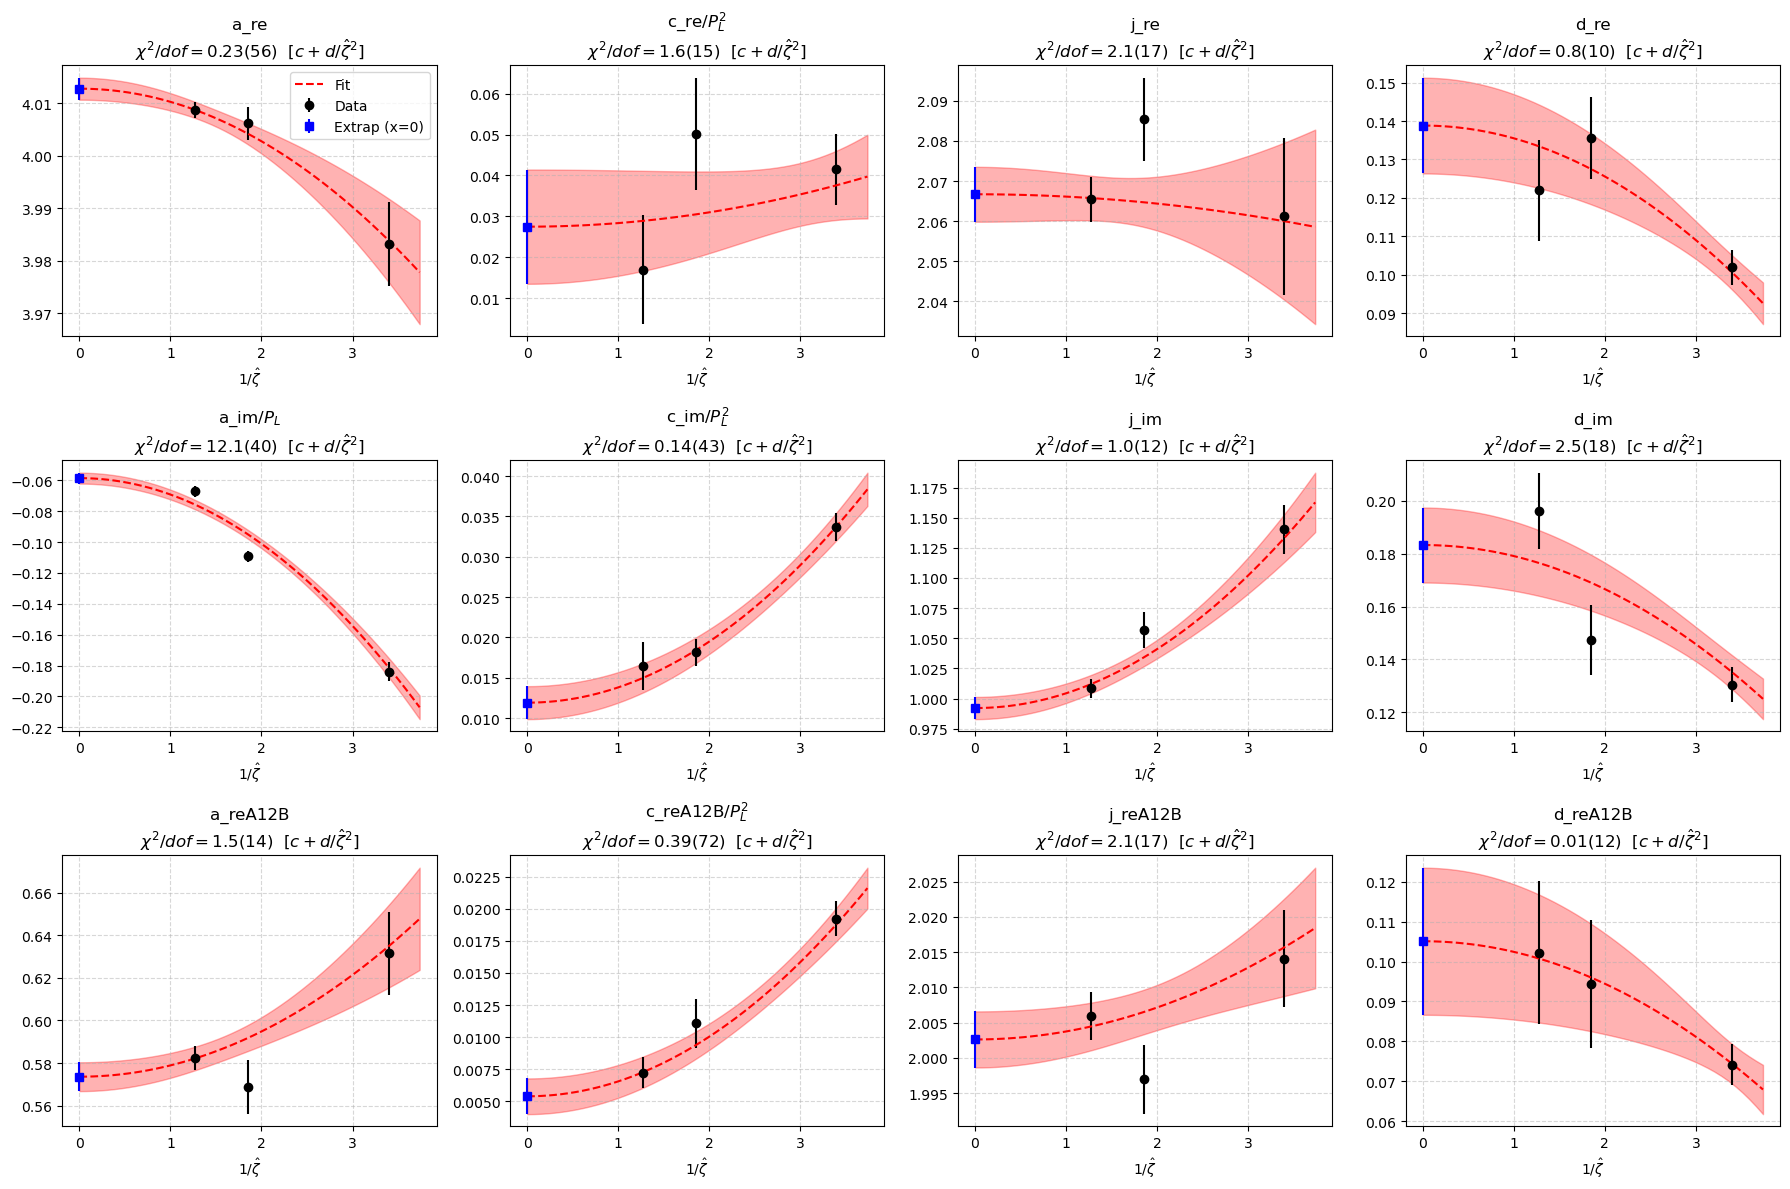


Computing Numerical Integrals across Jackknife samples...



### Numerical Integration of Fourier Transforms (|bT| = 0.34 fm)

| Integral | $\{-\infty, \infty\}$ | $\{-1, 1\}$ | $\{-1, 0\}$ | $\{0, 1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx \tilde{A}_{2B}^{\text{Re}}$ | 1.88(20) | 1.88(20) | 0.941(100) | 0.941(100) |
| $\int dx (i\tilde{A}_{2B}^{\text{Im}})$ | 2(23)e-16 | 7(52)e-16 | 0.413(68) | -0.423(72) |
| $\tilde{f}_1^{[1](0)} = 2\int dx (\tilde{A}_{2B}^{\text{Re}} - i\tilde{A}_{2B}^{\text{Im}})$ | 3.77(40) | 3.76(40) | 1.06(20) | 2.73(28) |
| $\tilde{f}_{1T}^{\perp[1](1)} = -2\int dx \tilde{A}_{12B}$ | 0.76(13) | 0.76(13) | 0.379(67) | 0.379(67) |
| $m_N \frac{\tilde{f}_{1T}^{\perp[1](1)}}{\tilde{f}_1^{[1](0)}}$ | 0.217(38) | 0.217(38) | 0.387(89) | 0.150(26) |


[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...


Evaluating x slices:   0%|          | 0/200 [00:00<?, ?it/s]

[4] Generating Final Plots...


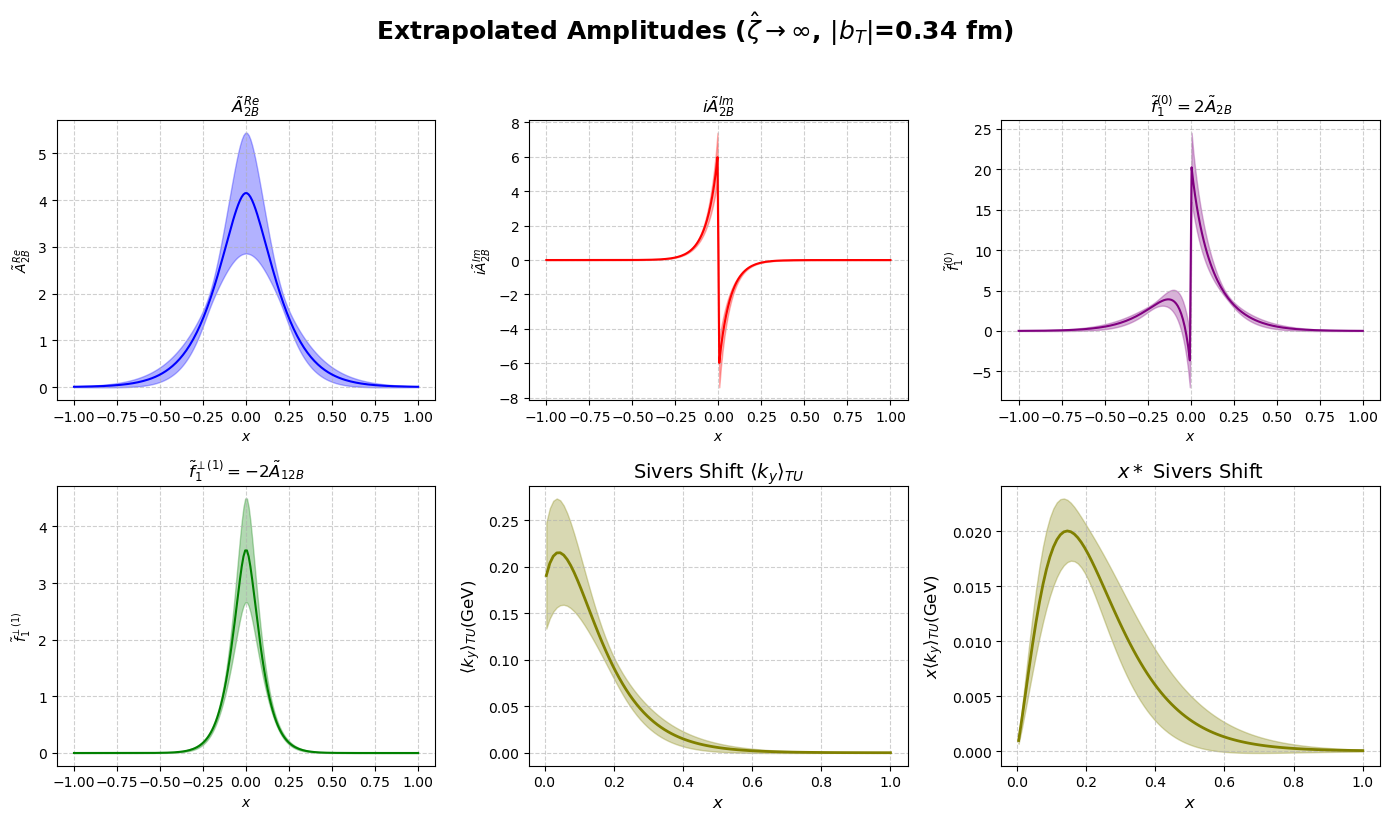


Evaluating Fourier transforms and applying Jackknife for 3D Plotting...


Evaluating over b^2 grid:   0%|          | 0/40 [00:00<?, ?it/s]

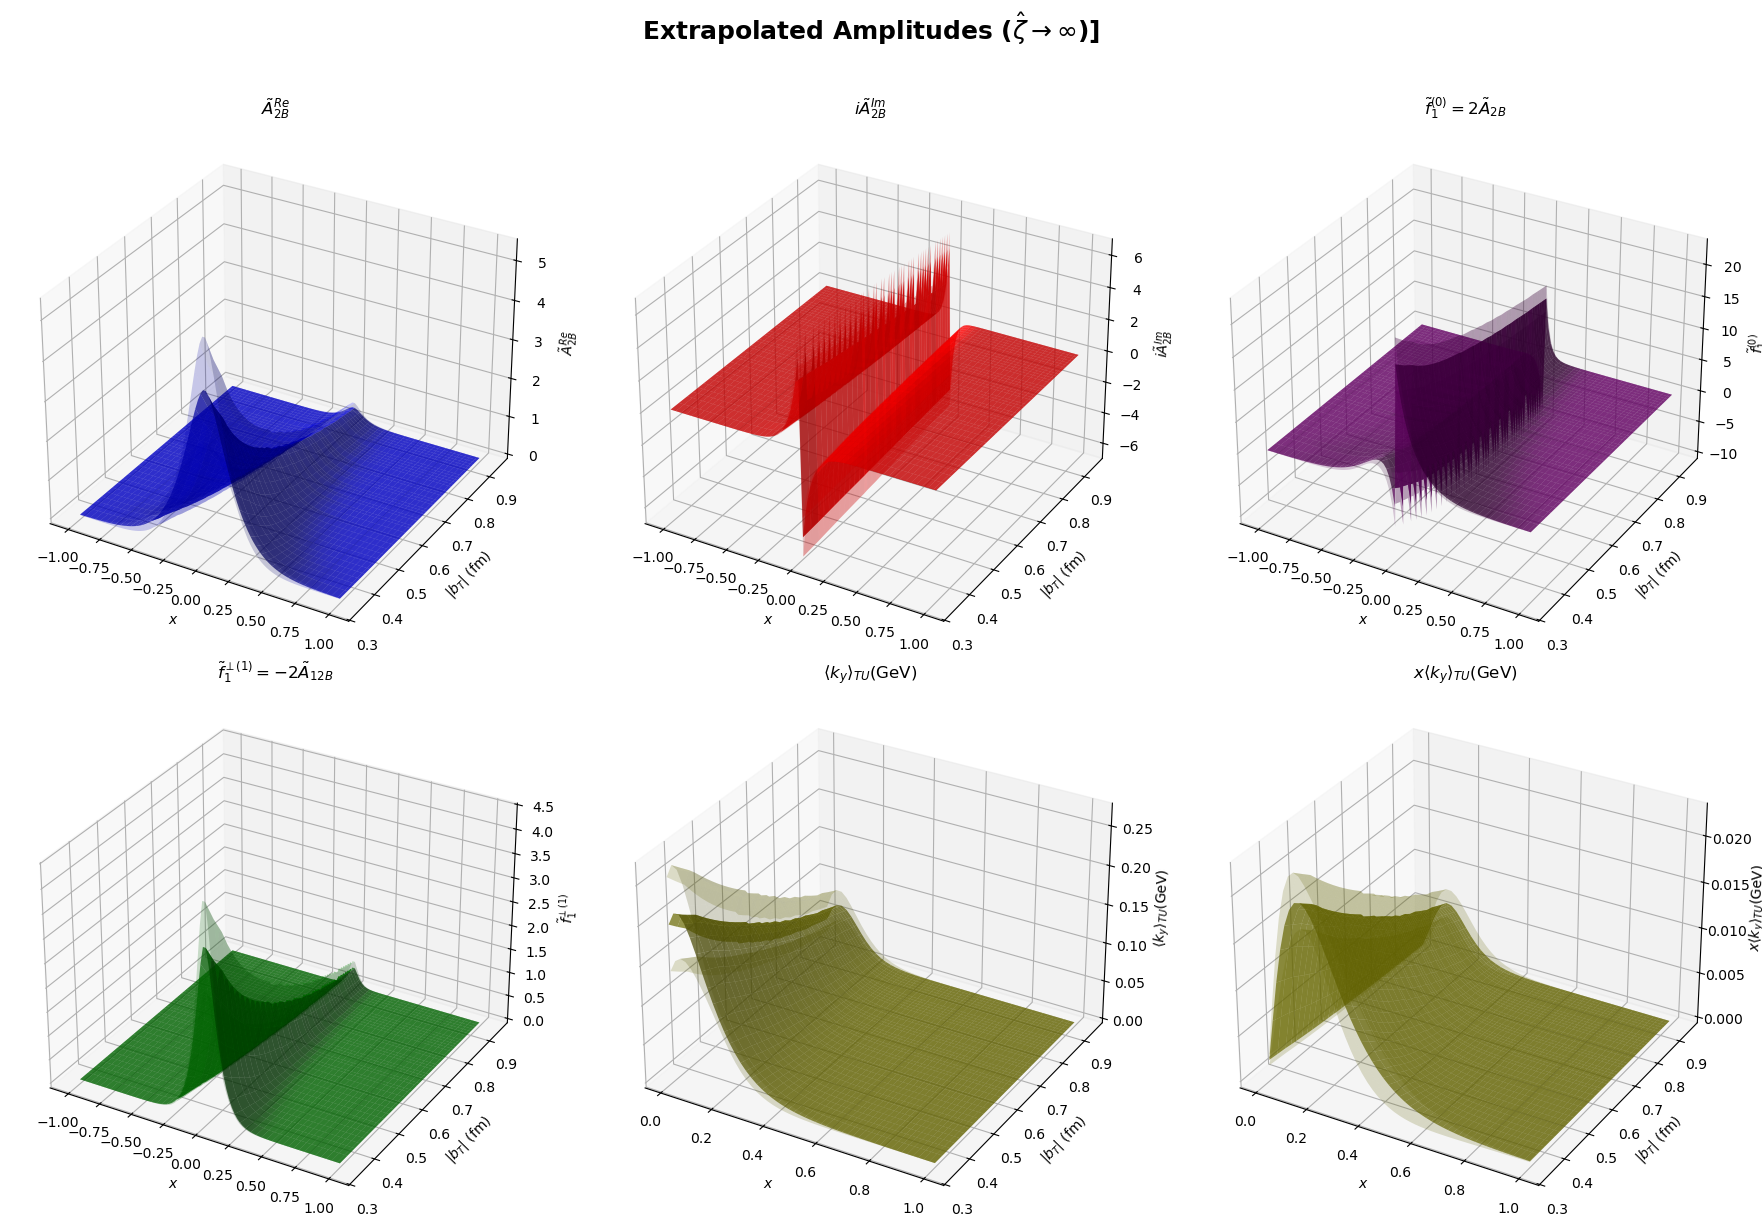


[5] Generating 2D Overlay Plot for all momenta + Extrapolated at fixed b^2 = 9.0...


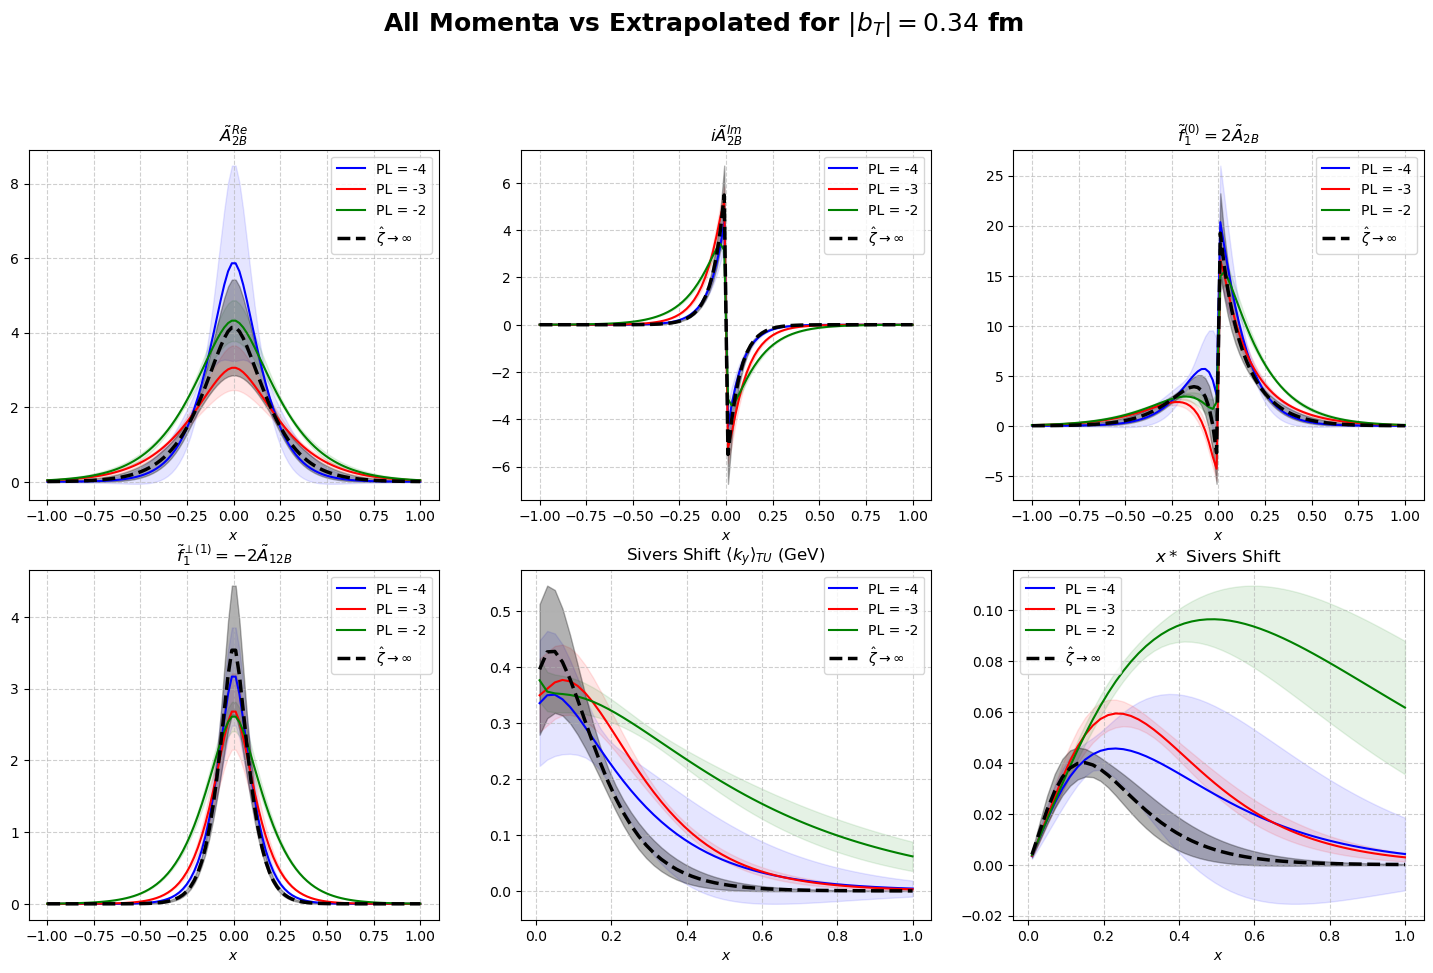

In [19]:
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-2, -3, -4]

    parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=200)

In [16]:
import h5py
import numpy as np
import math
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Helpers & Statistics
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    if err <= 0: return f"{mean}"
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
    else:
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1)) 
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
    return fitted_params

# ---------------------------------------------------------
# 2. Extrapolation Routine for Parameters
# ---------------------------------------------------------
def fit_param_linear(inv_zeta_vals, param_jk_samples):
    """
    Fits y = c0 + c1 * (1/zeta_hat) for a given parameter.
    """
    N_PL, N_JK = param_jk_samples.shape

    mean_y = np.mean(param_jk_samples, axis=1)
    cov_y = np.cov(param_jk_samples, bias=True) * (N_JK - 1)

    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    # Linear fit in 1/zeta_hat
    def fcn(x, p):
        return p['c0'] + p['c1'] * x**2

    prior = {'c0': gv.gvar(0, 5000000), 'c1': gv.gvar(0, 5000000)}

    # JK fits
    c0_jk = []
    c1_jk = []
    chi2_dof = []
    cov_y_eval = gv.evalcov(y_gvar)

    for k in range(N_JK):
        y_k_gvar = gv.gvar(param_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_k_gvar), fcn=fcn, prior=prior)
        chi2_dof.append(fit_k.chi2 / fit_k.dof)
        c0_jk.append(fit_k.pmean['c0'])
        c1_jk.append(fit_k.pmean['c1'])

    return np.array(c0_jk), np.array(c1_jk), np.array(chi2_dof)


def fit_param_linear_aim(inv_zeta_vals, param_jk_samples, powere_zata):
    """
    Fits y = c0 + c1 * (1/zeta_hat) for a given parameter.
    """
    N_PL, N_JK = param_jk_samples.shape

    mean_y = np.mean(param_jk_samples, axis=1)
    cov_y = np.cov(param_jk_samples, bias=True) * (N_JK - 1)

    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    # Linear fit in 1/zeta_hat
    def fcn(x, p):
        return p['c0'] + p['c1'] * x**powere_zata

    prior = {'c0': gv.gvar(0, 5000000), 'c1': gv.gvar(0, 5000000)}

    # JK fits
    c0_jk = []
    c1_jk = []
    chi2_dof = []
    cov_y_eval = gv.evalcov(y_gvar)

    for k in range(N_JK):
        y_k_gvar = gv.gvar(param_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_k_gvar), fcn=fcn, prior=prior)
        chi2_dof.append(fit_k.chi2 / fit_k.dof)
        c0_jk.append(fit_k.pmean['c0'])
        c1_jk.append(fit_k.pmean['c1'])

    return np.array(c0_jk), np.array(c1_jk), np.array(chi2_dof)

# ---------------------------------------------------------
# 3. Main Routine
# ---------------------------------------------------------
def parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=200):
    
    lata = 0.11403
    mass_filepath = "/pscratch/sd/h/hari_8/TMD_fit/h5data/MassN_Jackknife.h5"
    with h5py.File(mass_filepath, "r") as f:
        # This loads the mass array of shape (N_JK,)
        MassN_jk = f[f"PL_{-1}"][:] 
    massterm = MassN_jk * (197.32698 * 0.001 / lata)

    pl_to_zeta = {
        -4: 0.785756,
        -3: 0.539684,
        -2: 0.294367,
        -1: 0.090772
    }
    
    inv_zeta_vals = np.array([1.0 / pl_to_zeta[pl] for pl in PL_list])
    sort_idx = np.argsort(inv_zeta_vals)
    inv_zeta_vals = inv_zeta_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)
    
    # Create dynamic PL string for filenames (e.g. [-2, -3, -4] -> "234")
    pl_str = "".join([str(abs(p)) for p in sorted(PL_list, reverse=True)])
    
    # Load Initial Data to get N_JK
    init_filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])

    # Dictionary to hold the scaled parameters for all PLs
    param_names = ['a_re', 'c_re', 'j_re', 'd_re', 
                   'a_im', 'c_im', 'j_im', 'd_im', 
                   'a_reA12B', 'c_reA12B', 'j_reA12B', 'd_reA12B']
                   
    raw_data = {p: np.zeros((N_PL, N_JK)) for p in param_names}

    print("[1] Loading and Scaling Parameters...")
    for i, pl in enumerate(sorted_PL_list):
        filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        params = load_params_from_h5(filename)
        
        # Apply scaling rules
        raw_data['a_re'][i, :] = params['a_re']
        raw_data['c_re'][i, :] = params['c_re'] / (pl**2)
        raw_data['j_re'][i, :] = params['j_re']
        raw_data['d_re'][i, :] = params['d_re']
        
        raw_data['a_im'][i, :] = params['a_im'] / pl
        raw_data['c_im'][i, :] = params['c_im'] / (pl**2)
        raw_data['j_im'][i, :] = params['j_im']
        raw_data['d_im'][i, :] = params['d_im']
        
        raw_data['a_reA12B'][i, :] = params['a_reA12B']
        raw_data['c_reA12B'][i, :] = params['c_reA12B'] / (pl**2)
        raw_data['j_reA12B'][i, :] = params['j_reA12B']
        raw_data['d_reA12B'][i, :] = params['d_reA12B']

    print("[2] Extrapolating Parameters to 1/zeta_hat -> 0...")
    extrapolated_jk = {}
    
    # Plotting setup for parameters
    fig_p, axes_p = plt.subplots(3, 4, figsize=(18, 12))
    axes_p = axes_p.flatten()
    plot_x = np.linspace(0, max(inv_zeta_vals)*1.1, 50)

    for idx, p_name in enumerate(param_names):
        jk_samples = raw_data[p_name]
        
        # Fit
        powere_zata = 1.25
        if p_name == 'a_im':
            c0_jk, c1_jk, chi2 = fit_param_linear_aim(inv_zeta_vals, jk_samples, powere_zata)
        else:
            c0_jk, c1_jk, chi2 = fit_param_linear(inv_zeta_vals, jk_samples)
        extrapolated_jk[p_name] = c0_jk
        
        # Get means and errors for the raw data points
        y_means = np.mean(jk_samples, axis=1)
        y_errs = [Jackknife(jk_samples[i, :])[1] for i in range(N_PL)]
        
        # Generate Error Band for the fit line
        fit_m = np.zeros(len(plot_x))
        fit_e = np.zeros(len(plot_x))
        for i_x, px in enumerate(plot_x):
            # Evaluate the linear fit at this x for all JK samples
            if p_name == 'a_im':
                jk_vals_at_x = c0_jk + c1_jk * px**powere_zata
            else:
                jk_vals_at_x = c0_jk + c1_jk * px**2
            fit_m[i_x], fit_e[i_x] = Jackknife(jk_vals_at_x)
        
        c0_m, c0_e = Jackknife(c0_jk)
        
        # Plot
        ax = axes_p[idx]
        ax.errorbar(inv_zeta_vals, y_means, yerr=y_errs, fmt='o', color='black', label='Data')
        ax.plot(plot_x, fit_m, color='red', linestyle='--', label='Fit')
        ax.fill_between(plot_x, fit_m - fit_e, fit_m + fit_e, color='red', alpha=0.3)
        ax.errorbar([0], [c0_m], yerr=[c0_e], fmt='s', color='blue', label='Extrap (x=0)')
        if p_name == 'c_re':
            p_name_plot = 'c_re/$P_L^2$'
        elif p_name == 'c_im':
            p_name_plot = 'c_im/$P_L^2$'
        elif p_name == 'c_reA12B':
            p_name_plot = 'c_reA12B/$P_L^2$'
        elif p_name == 'a_im':
            p_name_plot = 'a_im/$P_L$'
        else:
            p_name_plot = p_name

        if p_name == 'a_im':
            anzert = f" [$c+d/\\hat{{\\zeta}}^{{{powere_zata}}}$]"
        else:
            anzert = f" [$c+d/\\hat{{\\zeta}}^2$]"
        ax.set_title(f"{p_name_plot}\n$\\chi^2/dof = {fmt_err(*Jackknife(chi2))}$ {anzert}")
        ax.set_xlabel("$1/\\hat{\\zeta}$")
        ax.grid(True, linestyle='--', alpha=0.5)
        if idx == 0: ax.legend()

    plt.tight_layout()
    plt.savefig(f"Param_Extrapolations_1byZetahat_sq_P{pl_str}_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf")
    plt.show()

    
    # =========================================================================
    # NEW: Numerical Integration Section
    # =========================================================================

    a_re, c_re, d_re, j_re = extrapolated_jk['a_re'], extrapolated_jk['c_re'], 1.0 + extrapolated_jk['d_re'] * b2, extrapolated_jk['j_re']
    a_im, c_im, d_im, j_im = extrapolated_jk['a_im'], extrapolated_jk['c_im'], 1.0 + extrapolated_jk['d_im'] * b2, extrapolated_jk['j_im']
    a_reA12B, c_reA12B, d_reA12B, j_reA12B = -extrapolated_jk['a_reA12B'], extrapolated_jk['c_reA12B'], 1.0 + extrapolated_jk['d_reA12B'] * 9, extrapolated_jk['j_reA12B']

    print("\nComputing Numerical Integrals across Jackknife samples...")
    
    # Define dense integration grids
    # We approximate -infinity to infinity with -40 to 40 (exponential decay makes this exact)
    x_inf = np.linspace(-40, 40, 4000)[:, None]
    x_11  = np.linspace(-1, 1, 1000)[:, None]
    x_m10  = np.linspace(-1, 0, 1000)[:, None]
    x_01  = np.linspace(0, 1, 1000)[:, None]

    # Safeguard against exactly zero
    x_inf[x_inf == 0] = 1e-12
    x_11[x_11 == 0] = 1e-12
    x_01[x_01 == 0] = 1e-12
    x_m10[x_m10 == 0] = 1e-12

    def calc_integrals_for_grid(x_grid):
        """Vectorized evaluation and integration over a given x_grid"""
        abs_x = np.abs(x_grid)

        # ReA2B
        cd_R = c_re / d_re
        term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
        term2_R = abs_x**(-0.5 + j_re)
        bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
        re_evals = term1_R * term2_R * bessel_R

        # ImA2B
        cd_I = c_im / d_im
        term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
        term2_I = x_grid * abs_x**(-1.5 + j_im)
        bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
        im_evals = term1_I * term2_I * bessel_I

        # ReA12B
        cd_RA12B = c_reA12B / d_reA12B
        term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
        term2_RA12B = abs_x**(-0.5 + j_reA12B)
        bessel_RA12B = kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))
        reA12B_evals = term1_RA12B * term2_RA12B * bessel_RA12B

        # Integrate (trapz sums over axis 0, leaving an array of size N_samples)
        int_re = np.trapezoid(re_evals, x=x_grid.flatten(), axis=0)
        int_im = np.trapezoid(im_evals, x=x_grid.flatten(), axis=0)
        int_reA12B = np.trapezoid(reA12B_evals, x=x_grid.flatten(), axis=0)

        # Derived quantities
        f1_0 = 2 * (int_re - int_im)
        f1T_perp = -2 * int_reA12B
        sivers_ratio = massterm * f1T_perp / f1_0

        return int_re, int_im, f1_0, f1T_perp, sivers_ratio

    # Compute integrals for all three ranges
    res_inf = calc_integrals_for_grid(x_inf)
    res_11  = calc_integrals_for_grid(x_11)
    res_01  = calc_integrals_for_grid(x_01)
    res_m10  = calc_integrals_for_grid(x_m10)

    
    def format_jk(data):
        mean, err = Jackknife(data)
        return fmt_err(mean, err)

    #print_integration_latex_table(res_inf, res_11, res_m10, res_01, PL, bminfit)

    row1 = [format_jk(res_inf[0]), format_jk(res_11[0]), format_jk(res_m10[0]), format_jk(res_01[0])]
    row2 = [format_jk(res_inf[1]), format_jk(res_11[1]), format_jk(res_m10[1]), format_jk(res_01[1])]
    row3 = [format_jk(res_inf[2]), format_jk(res_11[2]), format_jk(res_m10[2]), format_jk(res_01[2])]
    row4 = [format_jk(res_inf[3]), format_jk(res_11[3]), format_jk(res_m10[3]), format_jk(res_01[3])]
    row5 = [format_jk(res_inf[4]), format_jk(res_11[4]), format_jk(res_m10[4]), format_jk(res_01[4])]

    # Build the Markdown table
    md_int = "\n### Numerical Integration of Fourier Transforms (|bT| = 0.34 fm)\n\n"
    md_int += "| Integral | $\\{-\\infty, \\infty\\}$ | $\\{-1, 1\\}$ | $\\{-1, 0\\}$ | $\\{0, 1\\}$ |\n"
    md_int += "| :--- | :--- | :--- | :--- | :--- |\n"
    md_int += f"| $\\int dx \\tilde{{A}}_{{2B}}^{{\\text{{Re}}}}$ | {row1[0]} | {row1[1]} | {row1[2]} | {row1[3]} |\n"
    md_int += f"| $\\int dx (i\\tilde{{A}}_{{2B}}^{{\\text{{Im}}}})$ | {row2[0]} | {row2[1]} | {row2[2]} | {row2[3]} |\n"
    md_int += f"| $\\tilde{{f}}_1^{{[1](0)}} = 2\\int dx (\\tilde{{A}}_{{2B}}^{{\\text{{Re}}}} - i\\tilde{{A}}_{{2B}}^{{\\text{{Im}}}})$ | {row3[0]} | {row3[1]} | {row3[2]} | {row3[3]} |\n"
    md_int += f"| $\\tilde{{f}}_{{1T}}^{{\\perp[1](1)}} = -2\\int dx \\tilde{{A}}_{{12B}}$ | {row4[0]} | {row4[1]} | {row4[2]} | {row4[3]} |\n"
    md_int += f"| $m_N \\frac{{\\tilde{{f}}_{{1T}}^{{\\perp[1](1)}}}}{{\\tilde{{f}}_1^{{[1](0)}}}}$ | {row5[0]} | {row5[1]} | {row5[2]} | {row5[3]} |\n"

    try:
        from IPython.display import display, Markdown
        display(Markdown(md_int))
    except ImportError:
        print(md_int)
    
        
    
    print("[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...")
    x_vals = np.linspace(-1, 1, num_points_x)
    
    # Pre-allocate arrays for all plot lines
    siv_m, siv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    xsiv_m, xsiv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    
    reA2B_m, reA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    imA2B_m, imA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    A2B_m, A2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    reA12B_m, reA12B_e = np.zeros(num_points_x), np.zeros(num_points_x)

    for j, x in enumerate(tqdm(x_vals, desc="Evaluating x slices")):
        abs_x = max(np.abs(x), 1e-12)
        safe_x = x if x != 0 else 1e-12
        
        # Extract the extrapolated parameters for this specific JK sample
        a_R, c_R, d_R, j_R = extrapolated_jk['a_re'], extrapolated_jk['c_re'], 1.0 + extrapolated_jk['d_re'] * b2, extrapolated_jk['j_re']
        a_I, c_I, d_I, j_I = extrapolated_jk['a_im'], extrapolated_jk['c_im'], 1.0 + extrapolated_jk['d_im'] * b2, extrapolated_jk['j_im']
        a_A, c_A, d_A, j_A = -extrapolated_jk['a_reA12B'], extrapolated_jk['c_reA12B'], 1.0 + extrapolated_jk['d_reA12B'] * b2, extrapolated_jk['j_reA12B']

        # ReA2B
        cd_R = c_R / d_R # Safeguard
        term1_R = (2**(1 - j_R) * a_R * cd_R**(-0.25 - j_R/2) * d_R**(-j_R)) / gamma(j_R)
        re_eval = term1_R * (abs_x**(-0.5 + j_R)) * kv(0.5 - j_R, abs_x / np.sqrt(cd_R))

        # ImA2B
        cd_I = c_I / d_I # Safeguard
        term1_I = (2**(1 - j_I) * a_I * cd_I**(0.25 * (-3 - 2*j_I)) * d_I**(-j_I)) / gamma(j_I)
        im_eval = term1_I * (safe_x * abs_x**(-1.5 + j_I)) * kv(1.5 - j_I, np.sqrt(d_I / c_I) * abs_x)

        # ReA12B
        cd_A = c_A / d_A # Safeguard
        term1_A = (2**(1 - j_A) * a_A * cd_A**(-0.25 - j_A/2) * d_A**(-j_A)) / gamma(j_A)
        reA12B_eval = term1_A * (abs_x**(-0.5 + j_A)) * kv(0.5 - j_A, abs_x / np.sqrt(cd_A))

        # Store exact values into JK slices
        reA2B_jk_slice = re_eval
        imA2B_jk_slice = im_eval
        reA12B_jk_slice = -2*reA12B_eval
        A2B_jk_slice = 2*(re_eval - im_eval)
        siv_jk_slice = (-massterm * reA12B_eval) / (re_eval - im_eval)

        # Jackknife the final reconstructed arrays to get standard means and errors
        siv_m[j], siv_e[j] = Jackknife(siv_jk_slice)
        xsiv_m[j], xsiv_e[j] = Jackknife(x * siv_jk_slice)
        
        reA2B_m[j], reA2B_e[j] = Jackknife(reA2B_jk_slice)
        imA2B_m[j], imA2B_e[j] = Jackknife(imA2B_jk_slice)
        reA12B_m[j], reA12B_e[j] = Jackknife(reA12B_jk_slice)
        A2B_m[j], A2B_e[j] = Jackknife(A2B_jk_slice)

    # ---------------------------------------------------------
    # 4. Final Plotting (6 Panel Layout)
    # ---------------------------------------------------------
    print("[4] Generating Final Plots...")
    fig_s, axes_s = plt.subplots(2, 3, figsize=(14, 8))
    ax1, ax2, ax3, ax4, ax5, ax6 = axes_s.flatten()

    # Real Plot
    ax1.plot(x_vals, reA2B_m, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, reA2B_m - reA2B_e, reA2B_m + reA2B_e, color='blue', alpha=0.3)
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, imA2B_m, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, imA2B_m - imA2B_e, imA2B_m + imA2B_e, color='red', alpha=0.3) 
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full f1 Plot
    ax3.plot(x_vals, A2B_m, color='purple', label='A2B Mean')
    ax3.fill_between(x_vals, A2B_m - A2B_e, A2B_m + A2B_e, color='purple', alpha=0.3)
    ax3.set_title(f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{f}}_{{1}}^{{(0)}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    # A12B Plot
    ax4.plot(x_vals, reA12B_m, color='green')
    ax4.fill_between(x_vals, reA12B_m - reA12B_e, reA12B_m + reA12B_e, color='green', alpha=0.3)
    ax4.set_title(f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$')
    ax4.set_xlabel('$x$')
    ax4.set_ylabel('$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')
    ax4.grid(True, linestyle='--', alpha=0.6)

    # Sivers Shift Plot
    mask = x_vals >= 0
    ax5.plot(x_vals[mask], siv_m[mask], color='olive', linewidth=2)
    ax5.fill_between(x_vals[mask], siv_m[mask] - siv_e[mask], siv_m[mask] + siv_e[mask], color='olive', alpha=0.3)
    ax5.set_title(f'Sivers Shift $\\langle k_{{y}} \\rangle_{{TU}}$', fontsize=14)
    ax5.set_xlabel('$x$', fontsize=12)
    ax5.set_ylabel('$\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax5.grid(True, linestyle='--', alpha=0.6)

    # x * Sivers Shift Plot
    ax6.plot(x_vals[mask], xsiv_m[mask], color='olive', linewidth=2)
    ax6.fill_between(x_vals[mask], xsiv_m[mask] - xsiv_e[mask], xsiv_m[mask] + xsiv_e[mask], color='olive', alpha=0.3)
    ax6.set_title(f'$x *$ Sivers Shift', fontsize=14)
    ax6.set_xlabel('$x$', fontsize=12)
    ax6.set_ylabel('$x\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax6.grid(True, linestyle='--', alpha=0.6)

    fig_s.suptitle(f'Extrapolated Amplitudes ($\\hat{{\\zeta}} \\to \\infty$, $|b_T|$={np.round(np.sqrt(b2)*lata, 2)} fm) ', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    file_name = f"Extrapolated_AmpLevel_P{pl_str}_Sivers_1_over_zetahat_sq_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

    # 3D plots with b^2
    num_points_b2=40
    num_points_x=100
    # 1. Setup Grids for x and b^2
    x_vals = np.linspace(-1, 1, num_points_x)
    b2_vals = np.linspace(9, 68, num_points_b2)
    X, B2 = np.meshgrid(x_vals, b2_vals)
    
    # Initialize 2D arrays to store means and errors
    shape = X.shape
    re_mean_2d, re_err_2d = np.zeros(shape), np.zeros(shape)
    im_mean_2d, im_err_2d = np.zeros(shape), np.zeros(shape)
    full_mean_2d, full_err_2d = np.zeros(shape), np.zeros(shape)
    reA12B_mean_2d, reA12B_err_2d = np.zeros(shape), np.zeros(shape)
    SiverseShift_mean_2d, SiverseShift_err_2d = np.zeros(shape), np.zeros(shape)
    xSiverseShift_mean_2d, xSiverseShift_err_2d = np.zeros(shape), np.zeros(shape)

    print("\nEvaluating Fourier transforms and applying Jackknife for 3D Plotting...")
    
    # Loop over b2 (rows of meshgrid) and x (cols of meshgrid)
    for i, b2_step in enumerate(tqdm(b2_vals, desc="Evaluating over b^2 grid")):
        a_re, c_re, d_re, j_re = extrapolated_jk['a_re'], extrapolated_jk['c_re'], 1.0 + extrapolated_jk['d_re'] * b2_step, extrapolated_jk['j_re']
        a_im, c_im, d_im, j_im = extrapolated_jk['a_im'], extrapolated_jk['c_im'], 1.0 + extrapolated_jk['d_im'] * b2_step, extrapolated_jk['j_im']
        a_reA12B, c_reA12B, d_reA12B, j_reA12B = -extrapolated_jk['a_reA12B'], extrapolated_jk['c_reA12B'], 1.0 + extrapolated_jk['d_reA12B'] * b2_step, extrapolated_jk['j_reA12B']

        for j, x in enumerate(x_vals):
            abs_x = np.abs(x)
            if abs_x == 0: 
                abs_x = 1e-12
                x = 1e-12

            # --- Evaluate Real Part ---
            cd_R = c_re / d_re
            term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
            term2_R = abs_x**(-0.5 + j_re)
            bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
            
            re_evals_at_x = term1_R * term2_R * bessel_R
            re_mean_2d[i, j], re_err_2d[i, j] = Jackknife(re_evals_at_x)

            # --- Evaluate Imaginary Part ---
            cd_I = c_im / d_im
            term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
            term2_I = x * abs_x**(-1.5 + j_im)
            bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
            
            im_evals_at_x = term1_I * term2_I * bessel_I
            im_mean_2d[i, j], im_err_2d[i, j] = Jackknife(im_evals_at_x)

            # --- Full A2B ---
            full_mean_2d[i, j], full_err_2d[i, j] = Jackknife(2*(re_evals_at_x - im_evals_at_x))

            # --- Evaluate ReA12B Part ---
            cd_RA12B = c_reA12B / d_reA12B
            term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
            term2_RA12B = abs_x**(-0.5 + j_reA12B)
            bessel_RA12B = kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))
            
            reA12B_evals_at_x = term1_RA12B * term2_RA12B * bessel_RA12B
            
            reA12B_mean_2d[i, j], reA12B_err_2d[i, j] = Jackknife(-2*reA12B_evals_at_x)

            # --- Sivers Shift ---
            m_SiverseShift, e_SiverseShift = Jackknife((-massterm*reA12B_evals_at_x)/(re_evals_at_x - im_evals_at_x))
            SiverseShift_mean_2d[i, j] = m_SiverseShift
            SiverseShift_err_2d[i, j] = e_SiverseShift

            # --- x * Sivers Shift ---
            m_xSiverseShift, e_xSiverseShift = Jackknife(x*(-massterm*reA12B_evals_at_x)/(re_evals_at_x - im_evals_at_x))
            xSiverseShift_mean_2d[i, j] = m_xSiverseShift
            xSiverseShift_err_2d[i, j] = e_xSiverseShift

    # 4. Plotting in 3D
    fig = plt.figure(figsize=(18, 12))

    # Helper function to plot 3D mean + error bands
    def plot_3d_band(ax, X_grid, Y_grid, Z_mean, Z_err, color_val, title_val, ylabel_val):
        # Mean Surface
        ax.plot_surface(X_grid, Y_grid, Z_mean, color=color_val, alpha=0.7, edgecolor='none')
        # Upper Error Surface
        ax.plot_surface(X_grid, Y_grid, Z_mean + Z_err, color=color_val, alpha=0.2, edgecolor='none')
        # Lower Error Surface
        ax.plot_surface(X_grid, Y_grid, Z_mean - Z_err, color=color_val, alpha=0.2, edgecolor='none')
        
        ax.set_title(title_val)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$|b_T|$ (fm)')
        ax.set_zlabel(ylabel_val)

    b2_vals_plot = np.round(np.sqrt(b2_vals)*lata, 2)
    B2_plot = np.round(np.sqrt(B2)*lata, 2)
    
    # 1. Real Plot
    ax1 = fig.add_subplot(231, projection='3d')
    plot_3d_band(ax1, X, B2_plot, re_mean_2d, re_err_2d, 'blue', f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ', '$\\tilde{{A}}_{{2B}}^{{Re}}$')

    # 2. Imaginary Plot
    ax2 = fig.add_subplot(232, projection='3d')
    plot_3d_band(ax2, X, B2_plot, im_mean_2d, im_err_2d, 'red', f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ', '$i\\tilde{{A}}_{{2B}}^{{Im}}$')

    # 3. Full f1 Plot
    ax3 = fig.add_subplot(233, projection='3d')
    plot_3d_band(ax3, X, B2_plot, full_mean_2d, full_err_2d, 'purple', f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ', '$\\tilde{{f}}_{{1}}^{{(0)}}$')

    # 4. A12B Plot
    ax4 = fig.add_subplot(234, projection='3d')
    plot_3d_band(ax4, X, B2_plot, reA12B_mean_2d, reA12B_err_2d, 'green', f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ', '$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')

    # Create masks and sub-grids for x >= 0 (plots 5 and 6)
    mask_idx = np.where(x_vals >= 0)[0]
    x_vals_pos = x_vals[mask_idx]
    X_pos, B2_pos = np.meshgrid(x_vals_pos, b2_vals_plot)
    
    SiverseShift_mean_pos = SiverseShift_mean_2d[:, mask_idx]
    SiverseShift_err_pos = SiverseShift_err_2d[:, mask_idx]
    
    xSiverseShift_mean_pos = xSiverseShift_mean_2d[:, mask_idx]
    xSiverseShift_err_pos = xSiverseShift_err_2d[:, mask_idx]

    # 5. Sivers Shift Plot (0 to 1)
    ax5 = fig.add_subplot(235, projection='3d')
    plot_3d_band(ax5, X_pos, B2_pos, SiverseShift_mean_pos, SiverseShift_err_pos, 'olive', 
                 f'$\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ', '$\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')

    # 6. x*Sivers Shift Plot (0 to 1)
    ax6 = fig.add_subplot(236, projection='3d')
    plot_3d_band(ax6, X_pos, B2_pos, xSiverseShift_mean_pos, xSiverseShift_err_pos, 'olive', 
                 f'$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ', '$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')

    fig.suptitle(f'Extrapolated Amplitudes ($\\hat{{\\zeta}} \\to \\infty$)', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    file_name = f"SimulFitCovMatrix-A12B-A2B-FT-3D__bmin{bminfit}_eta{etamin}{etamax}_PLInf.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # 5. Fixed b^2 2D Overlay: All finite Momenta + Extrapolated (Black)
    # ---------------------------------------------------------
    print(f"\n[5] Generating 2D Overlay Plot for all momenta + Extrapolated at fixed b^2 = {b2}...")
    
    fig_over, axes_over = plt.subplots(2, 3, figsize=(18, 10))
    ax1_o, ax2_o, ax3_o, ax4_o, ax5_o, ax6_o = axes_over.flatten()

    colors = ['blue', 'red', 'green', 'purple', 'orange', 'cyan'] # Distinct colors for finite PLs

    # Helper function using vectorization over all JK samples to eliminate loop overhead
    def eval_1D_vectorized(p_dict, b2_val):
        abs_x = np.abs(x_vals)
        abs_x[abs_x == 0] = 1e-12
        safe_x = np.where(x_vals == 0, 1e-12, x_vals)

        a_R, c_R, d_R, j_R = p_dict['a_re'][:,None], p_dict['c_re'][:,None], (1.0 + p_dict['d_re']*b2_val)[:,None], p_dict['j_re'][:,None]
        a_I, c_I, d_I, j_I = p_dict['a_im'][:,None], p_dict['c_im'][:,None], (1.0 + p_dict['d_im']*b2_val)[:,None], p_dict['j_im'][:,None]
        a_A, c_A, d_A, j_A = -p_dict['a_reA12B'][:,None], p_dict['c_reA12B'][:,None], (1.0 + p_dict['d_reA12B']*b2_val)[:,None], p_dict['j_reA12B'][:,None]

        mt = massterm[:, None]

        cd_R = c_R / d_R
        t1_R = (2**(1 - j_R) * a_R * cd_R**(-0.25 - j_R/2) * d_R**(-j_R)) / gamma(j_R)
        re = t1_R * (abs_x[None, :]**(-0.5 + j_R)) * kv(0.5 - j_R, abs_x[None, :] / np.sqrt(cd_R))

        cd_I = c_I / d_I
        t1_I = (2**(1 - j_I) * a_I * cd_I**(0.25 * (-3 - 2*j_I)) * d_I**(-j_I)) / gamma(j_I)
        im = t1_I * (safe_x[None, :] * abs_x[None, :]**(-1.5 + j_I)) * kv(1.5 - j_I, np.sqrt(d_I / c_I) * abs_x[None, :])

        cd_A = c_A / d_A
        t1_A = (2**(1 - j_A) * a_A * cd_A**(-0.25 - j_A/2) * d_A**(-j_A)) / gamma(j_A)
        reA12B = -2 * t1_A * (abs_x[None, :]**(-0.5 + j_A)) * kv(0.5 - j_A, abs_x[None, :] / np.sqrt(cd_A))

        full = 2 * (re - im)
        siv = (mt * reA12B) / (re - im)
        xsiv = safe_x[None, :] * siv

        def jk(data):
            N = data.shape[0]
            m = np.mean(data, axis=0)
            e = np.sqrt(((N-1)/N) * np.sum((data - m)**2, axis=0))
            return m, e

        return { 're': jk(re), 'im': jk(im), 'full': jk(full), 'A12B': jk(reA12B), 'siv': jk(siv), 'xsiv': jk(xsiv) }

    # Plot Finite Momenta Slices
    for i, pl in enumerate(sorted_PL_list):
        p_dict = {k: raw_data[k][i] for k in param_names}
        res = eval_1D_vectorized(p_dict, b2)
        c = colors[i % len(colors)]
        lbl = f"PL = {pl}"

        ax1_o.plot(x_vals, res['re'][0], color=c, label=lbl)
        ax1_o.fill_between(x_vals, res['re'][0]-res['re'][1], res['re'][0]+res['re'][1], color=c, alpha=0.1)

        ax2_o.plot(x_vals, res['im'][0], color=c, label=lbl)
        ax2_o.fill_between(x_vals, res['im'][0]-res['im'][1], res['im'][0]+res['im'][1], color=c, alpha=0.1)

        ax3_o.plot(x_vals, res['full'][0], color=c, label=lbl)
        ax3_o.fill_between(x_vals, res['full'][0]-res['full'][1], res['full'][0]+res['full'][1], color=c, alpha=0.1)

        ax4_o.plot(x_vals, res['A12B'][0], color=c, label=lbl)
        ax4_o.fill_between(x_vals, res['A12B'][0]-res['A12B'][1], res['A12B'][0]+res['A12B'][1], color=c, alpha=0.1)

        ax5_o.plot(x_vals[mask_idx], res['siv'][0][mask_idx], color=c, label=lbl)
        ax5_o.fill_between(x_vals[mask_idx], res['siv'][0][mask_idx]-res['siv'][1][mask_idx], res['siv'][0][mask_idx]+res['siv'][1][mask_idx], color=c, alpha=0.1)

        ax6_o.plot(x_vals[mask_idx], res['xsiv'][0][mask_idx], color=c, label=lbl)
        ax6_o.fill_between(x_vals[mask_idx], res['xsiv'][0][mask_idx]-res['xsiv'][1][mask_idx], res['xsiv'][0][mask_idx]+res['xsiv'][1][mask_idx], color=c, alpha=0.1)

    # Plot Extrapolated Limit in BOLD BLACK
    res_ex = eval_1D_vectorized(extrapolated_jk, b2)
    lbl = r"$\hat{\zeta} \to \infty$"
    c = 'black'

    ax1_o.plot(x_vals, res_ex['re'][0], color=c, linewidth=2.5, linestyle='--', label=lbl)
    ax1_o.fill_between(x_vals, res_ex['re'][0]-res_ex['re'][1], res_ex['re'][0]+res_ex['re'][1], color=c, alpha=0.3)

    ax2_o.plot(x_vals, res_ex['im'][0], color=c, linewidth=2.5, linestyle='--', label=lbl)
    ax2_o.fill_between(x_vals, res_ex['im'][0]-res_ex['im'][1], res_ex['im'][0]+res_ex['im'][1], color=c, alpha=0.3)

    ax3_o.plot(x_vals, res_ex['full'][0], color=c, linewidth=2.5, linestyle='--', label=lbl)
    ax3_o.fill_between(x_vals, res_ex['full'][0]-res_ex['full'][1], res_ex['full'][0]+res_ex['full'][1], color=c, alpha=0.3)

    ax4_o.plot(x_vals, res_ex['A12B'][0], color=c, linewidth=2.5, linestyle='--', label=lbl)
    ax4_o.fill_between(x_vals, res_ex['A12B'][0]-res_ex['A12B'][1], res_ex['A12B'][0]+res_ex['A12B'][1], color=c, alpha=0.3)

    ax5_o.plot(x_vals[mask_idx], res_ex['siv'][0][mask_idx], color=c, linewidth=2.5, linestyle='--', label=lbl)
    ax5_o.fill_between(x_vals[mask_idx], res_ex['siv'][0][mask_idx]-res_ex['siv'][1][mask_idx], res_ex['siv'][0][mask_idx]+res_ex['siv'][1][mask_idx], color=c, alpha=0.3)

    ax6_o.plot(x_vals[mask_idx], res_ex['xsiv'][0][mask_idx], color=c, linewidth=2.5, linestyle='--', label=lbl)
    ax6_o.fill_between(x_vals[mask_idx], res_ex['xsiv'][0][mask_idx]-res_ex['xsiv'][1][mask_idx], res_ex['xsiv'][0][mask_idx]+res_ex['xsiv'][1][mask_idx], color=c, alpha=0.3)

    # Formatting Overlays
    ax1_o.set_title(r'$\tilde{A}_{2B}^{Re}$'); ax1_o.set_xlabel('$x$')
    ax2_o.set_title(r'$i\tilde{A}_{2B}^{Im}$'); ax2_o.set_xlabel('$x$')
    ax3_o.set_title(r'$\tilde{f}_{1}^{(0)}=2\tilde{A}_{2B}$'); ax3_o.set_xlabel('$x$')
    ax4_o.set_title(r'$\tilde{f}_{1}^{\perp(1)}=-2\tilde{A}_{12B}$'); ax4_o.set_xlabel('$x$')
    ax5_o.set_title(r'Sivers Shift $\langle k_y \rangle_{TU}$ (GeV)'); ax5_o.set_xlabel('$x$')
    ax6_o.set_title(r'$x * $ Sivers Shift'); ax6_o.set_xlabel('$x$')

    for ax in [ax1_o, ax2_o, ax3_o, ax4_o, ax5_o, ax6_o]:
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()

    bT_fm = np.round(np.sqrt(b2) * lata, 2)
    fig_over.suptitle(f'All Momenta vs Extrapolated for $|b_T| = {bT_fm}$ fm', fontsize=18, fontweight='bold', y=1.02)
    #plt.tight_layout()
    plt.savefig(f"All_Momenta_vs_Extrapolated_2D_P{pl_str}_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf", format='pdf', bbox_inches='tight')
    plt.show()



[1] Loading and Scaling Parameters...
[2] Extrapolating Parameters to 1/zeta_hat -> 0...


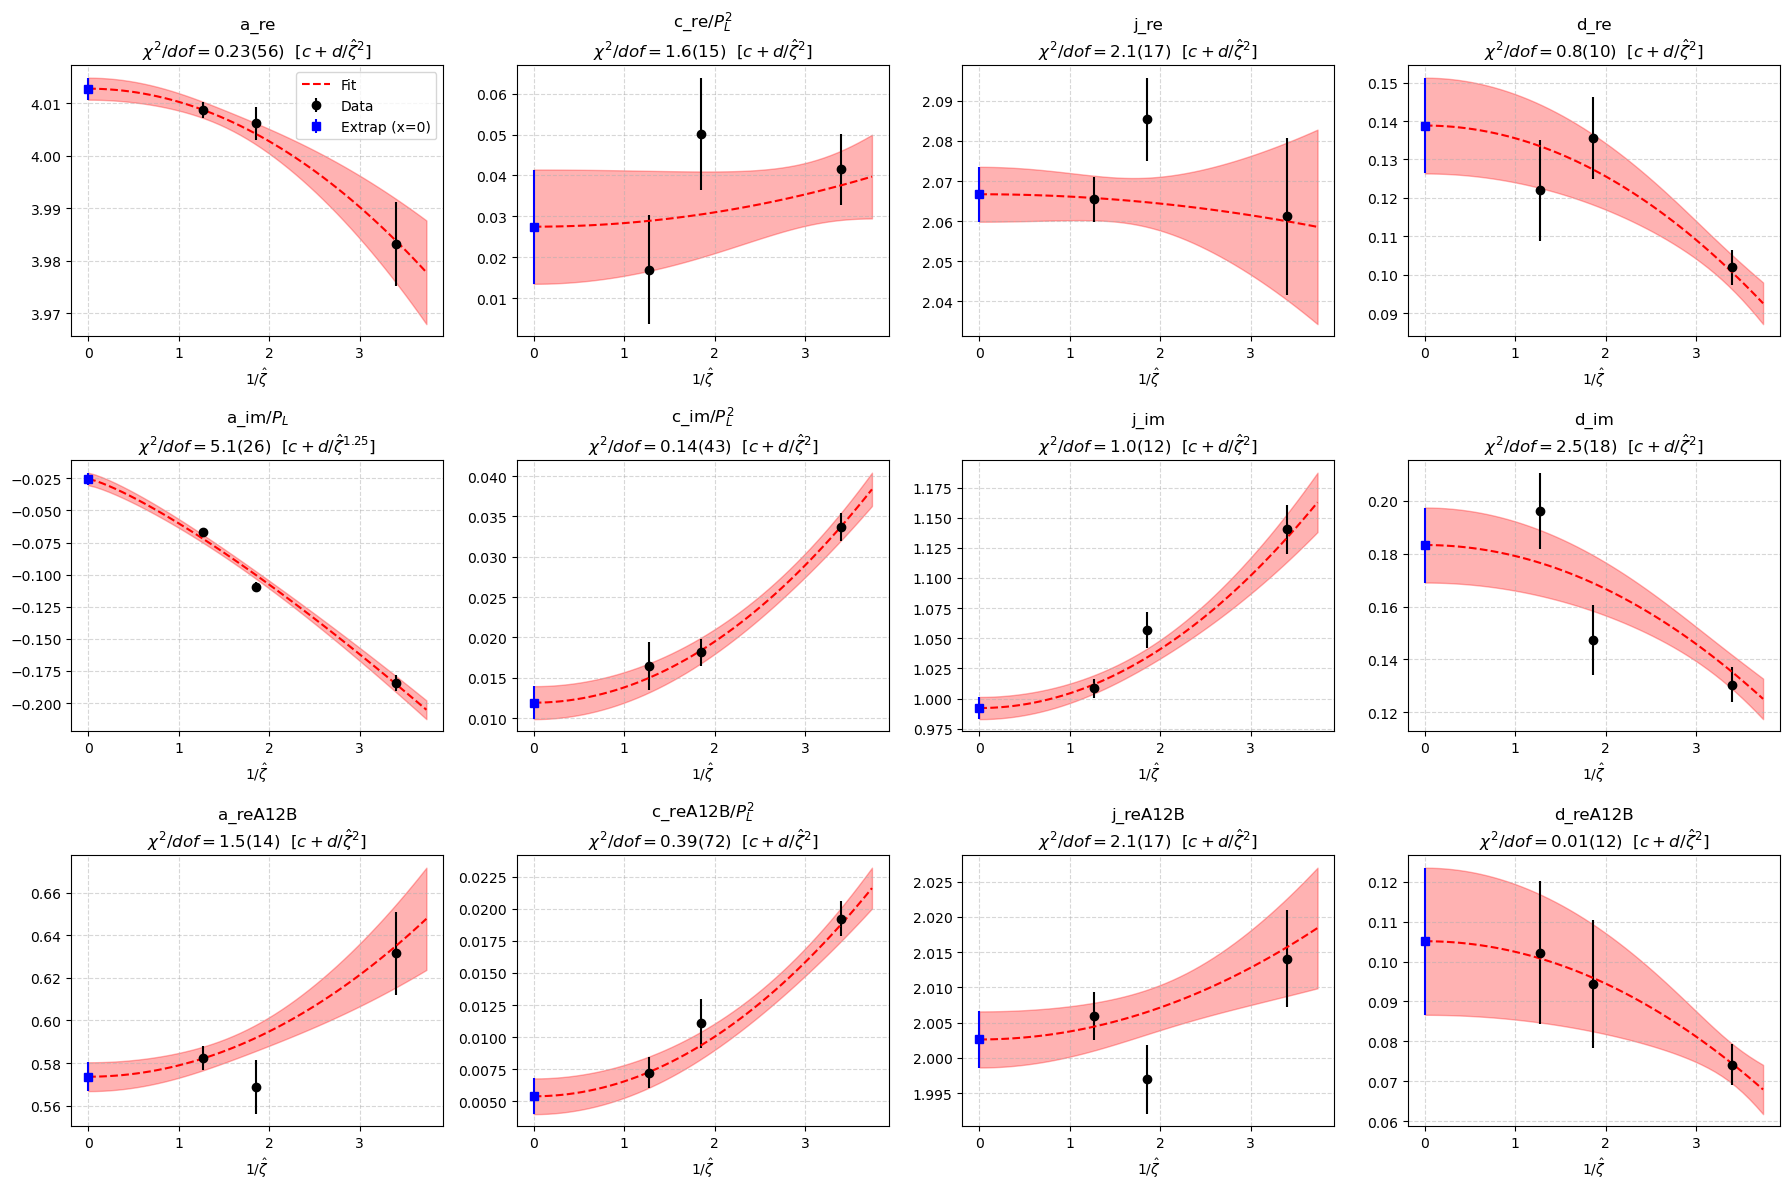


Computing Numerical Integrals across Jackknife samples...



### Numerical Integration of Fourier Transforms (|bT| = 0.34 fm)

| Integral | $\{-\infty, \infty\}$ | $\{-1, 1\}$ | $\{-1, 0\}$ | $\{0, 1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx \tilde{A}_{2B}^{\text{Re}}$ | 1.88(20) | 1.88(20) | 0.941(100) | 0.941(100) |
| $\int dx (i\tilde{A}_{2B}^{\text{Im}})$ | 7(103)e-17 | 3(25)e-16 | 0.180(50) | -0.184(52) |
| $\tilde{f}_1^{[1](0)} = 2\int dx (\tilde{A}_{2B}^{\text{Re}} - i\tilde{A}_{2B}^{\text{Im}})$ | 3.77(40) | 3.76(40) | 1.52(20) | 2.25(24) |
| $\tilde{f}_{1T}^{\perp[1](1)} = -2\int dx \tilde{A}_{12B}$ | 0.76(13) | 0.76(13) | 0.379(67) | 0.379(67) |
| $m_N \frac{\tilde{f}_{1T}^{\perp[1](1)}}{\tilde{f}_1^{[1](0)}}$ | 0.217(38) | 0.217(38) | 0.268(51) | 0.182(32) |


[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...


Evaluating x slices:   0%|          | 0/200 [00:00<?, ?it/s]

[4] Generating Final Plots...


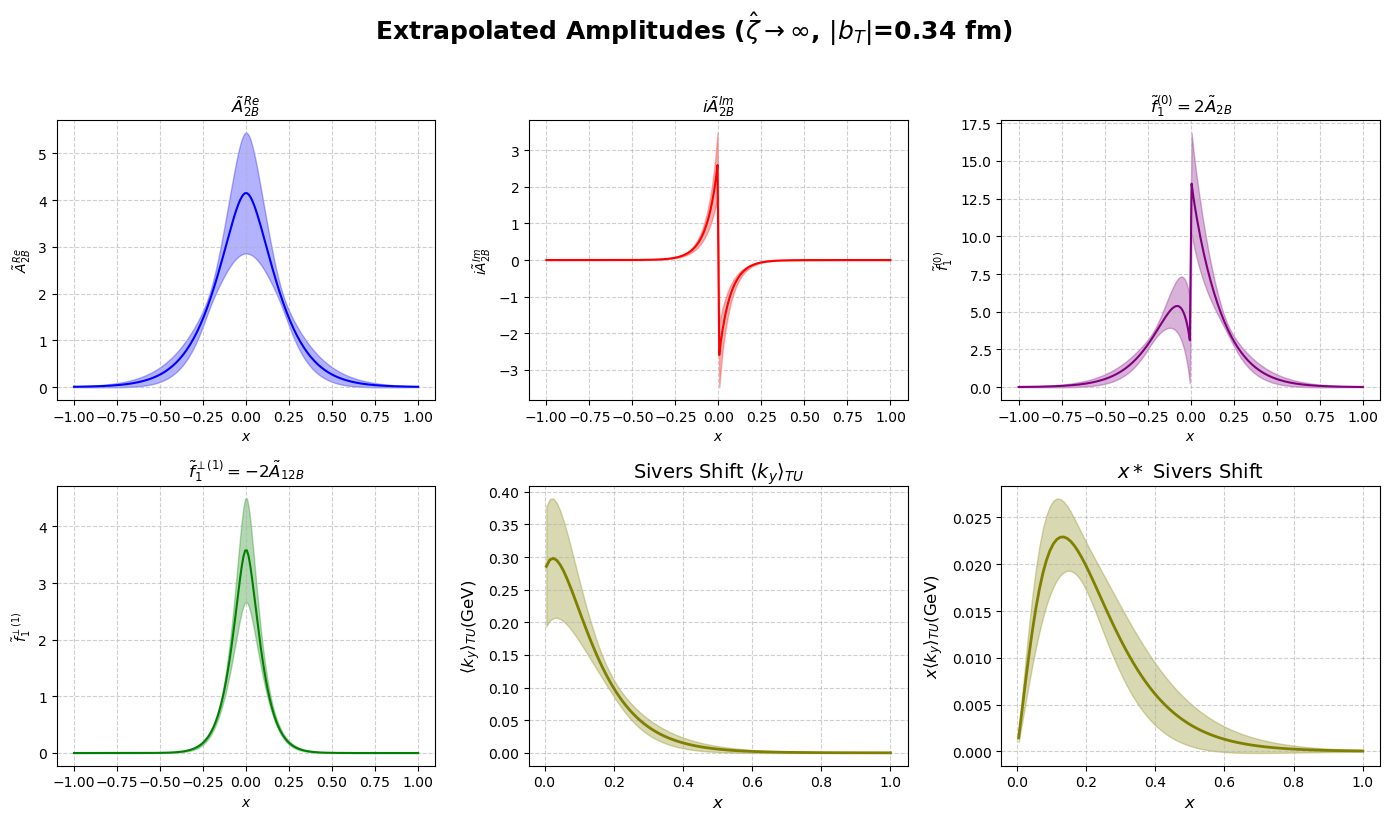


Evaluating Fourier transforms and applying Jackknife for 3D Plotting...


Evaluating over b^2 grid:   0%|          | 0/40 [00:00<?, ?it/s]

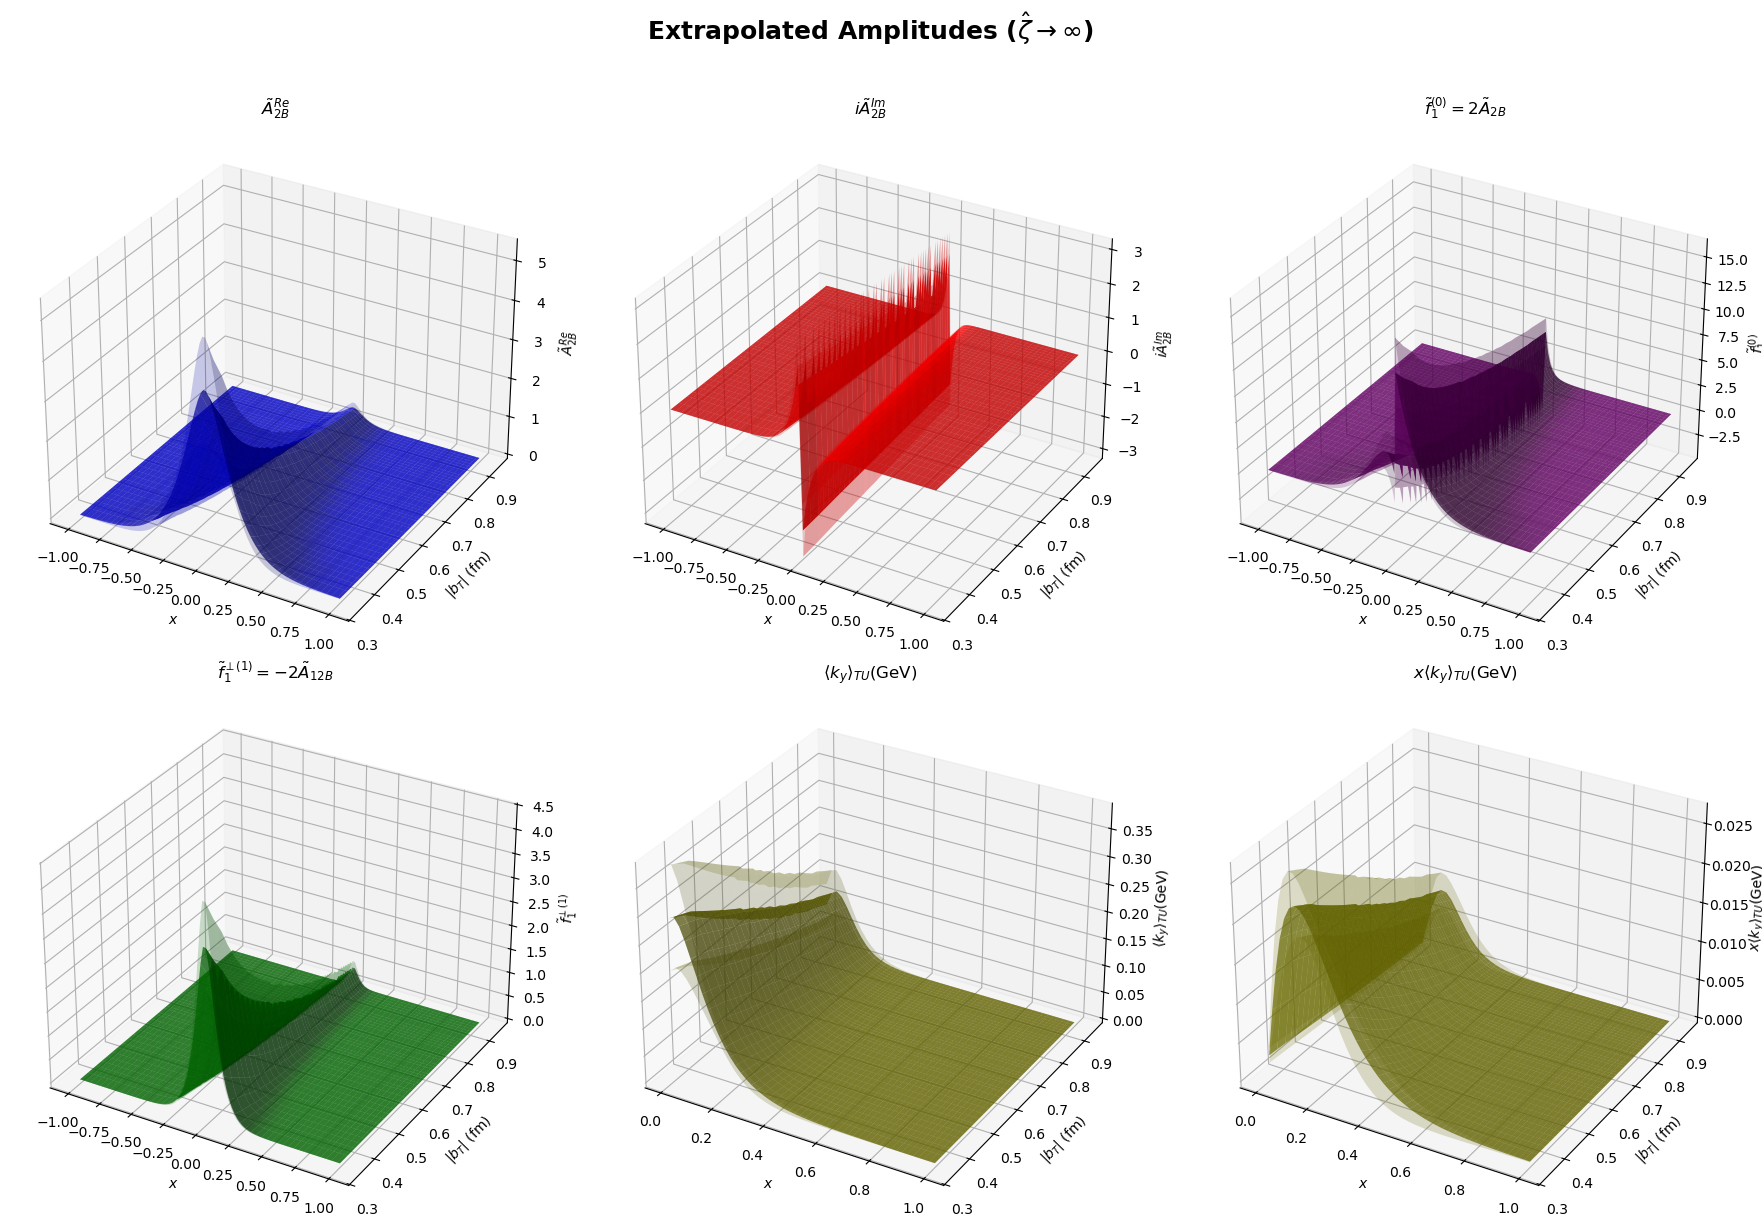


[5] Generating 2D Overlay Plot for all momenta + Extrapolated at fixed b^2 = 9.0...


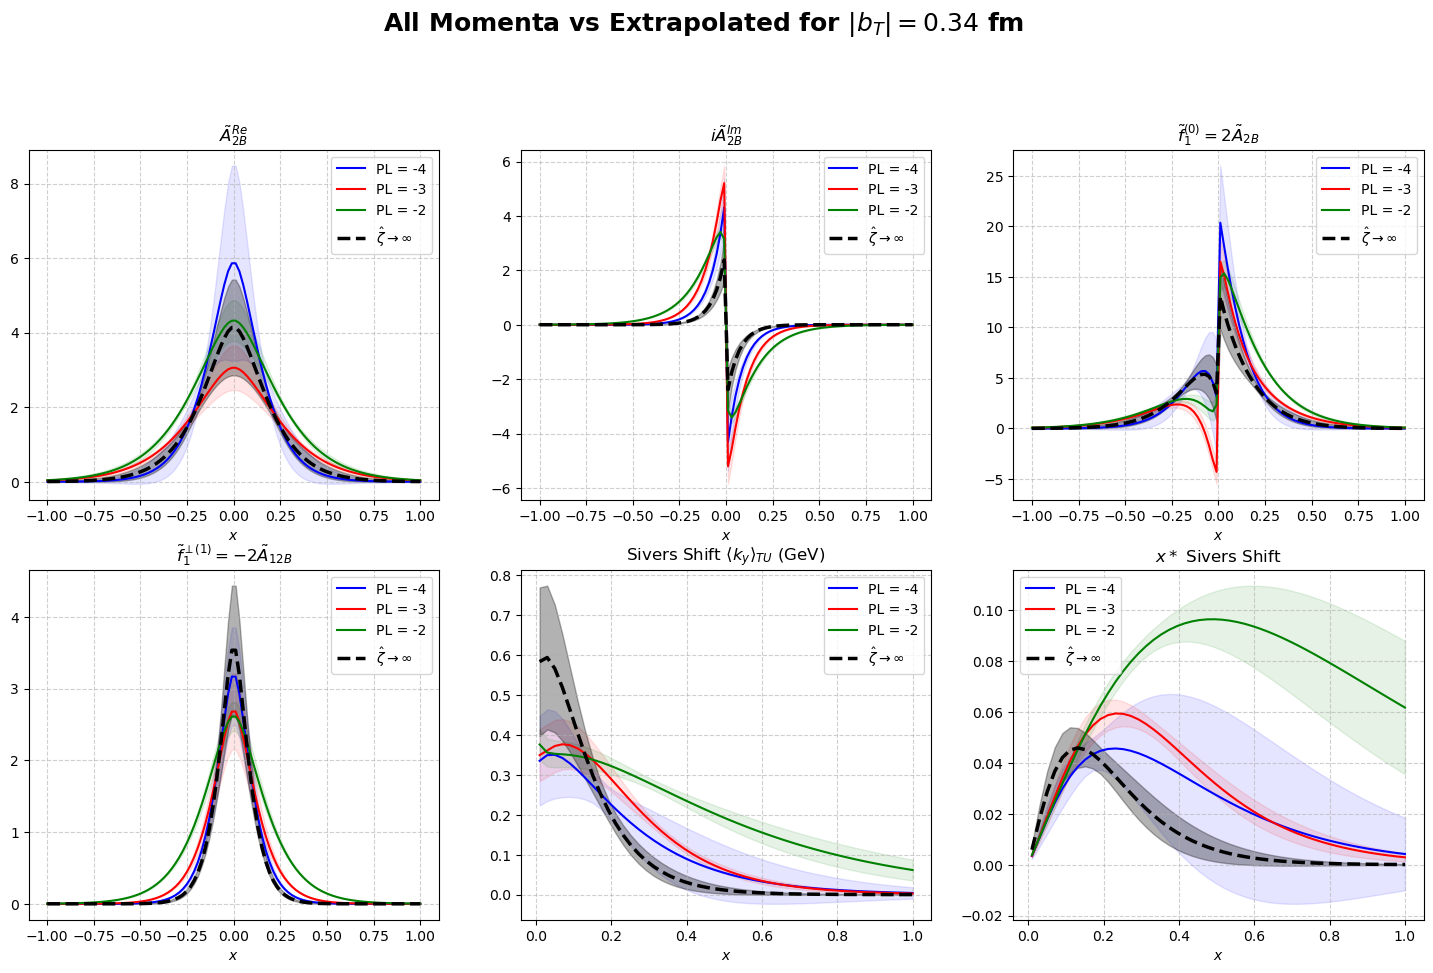

In [17]:
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-2, -3, -4]

    parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=200)